# Import required libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

# Load dataset

In [5]:
# Load dataset
df = pd.read_csv('/Users/Admin/Desktop/DS Project/Lead Scoring.csv')

# SECTION 1: DATA UNDERSTANDING


## 1.1: Basic structure


In [9]:
print("Shape of the DataFrame:", df.shape)
print("\nData Types:\n", df.dtypes)


Shape of the DataFrame: (9240, 37)

Data Types:
 Prospect ID                                       object
Lead Number                                        int64
Lead Origin                                       object
Lead Source                                       object
Do Not Email                                      object
Do Not Call                                       object
Converted                                          int64
TotalVisits                                      float64
Total Time Spent on Website                        int64
Page Views Per Visit                             float64
Last Activity                                     object
Country                                           object
Specialization                                    object
How did you hear about X Education                object
What is your current occupation                   object
What matters most to you in choosing a course     object
Search                                 

## 1.2: Head and tail


In [12]:
print("\nFirst 5 rows:\n")
df.tail(5)


First 5 rows:



,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
9235,19d6451e-fcd6-407c-b83b-48e1af805ea9,579564,Landing Page Submission,Direct Traffic,Yes,No,1,8.0,1845,2.67,...,No,Potential Lead,Mumbai,02.Medium,01.High,15.0,17.0,No,No,Email Marked Spam
9236,82a7005b-7196-4d56-95ce-a79f937a158d,579546,Landing Page Submission,Direct Traffic,No,No,0,2.0,238,2.00,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,19.0,No,Yes,SMS Sent
9237,aac550fe-a586-452d-8d3c-f1b62c94e02c,579545,Landing Page Submission,Direct Traffic,Yes,No,0,2.0,199,2.00,...,No,Potential Lead,Mumbai,02.Medium,01.High,13.0,20.0,No,Yes,SMS Sent
9238,5330a7d1-2f2b-4df4-85d6-64ca2f6b95b9,579538,Landing Page Submission,Google,No,No,1,3.0,499,3.00,...,No,NaN,Other Metro Cities,02.Medium,02.Medium,15.0,16.0,No,No,SMS Sent
9239,571b5c8e-a5b2-4d57-8574-f2ffb06fdeff,579533,Landing Page Submission,Direct Traffic,No,No,1,6.0,1279,3.00,...,No,Potential Lead,Other Cities,02.Medium,01.High,15.0,18.0,No,Yes,Modified


In [14]:
print("\nLast 5 rows:\n")
df.tail(5)


Last 5 rows:



,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
9235,19d6451e-fcd6-407c-b83b-48e1af805ea9,579564,Landing Page Submission,Direct Traffic,Yes,No,1,8.0,1845,2.67,...,No,Potential Lead,Mumbai,02.Medium,01.High,15.0,17.0,No,No,Email Marked Spam
9236,82a7005b-7196-4d56-95ce-a79f937a158d,579546,Landing Page Submission,Direct Traffic,No,No,0,2.0,238,2.00,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,19.0,No,Yes,SMS Sent
9237,aac550fe-a586-452d-8d3c-f1b62c94e02c,579545,Landing Page Submission,Direct Traffic,Yes,No,0,2.0,199,2.00,...,No,Potential Lead,Mumbai,02.Medium,01.High,13.0,20.0,No,Yes,SMS Sent
9238,5330a7d1-2f2b-4df4-85d6-64ca2f6b95b9,579538,Landing Page Submission,Google,No,No,1,3.0,499,3.00,...,No,NaN,Other Metro Cities,02.Medium,02.Medium,15.0,16.0,No,No,SMS Sent
9239,571b5c8e-a5b2-4d57-8574-f2ffb06fdeff,579533,Landing Page Submission,Direct Traffic,No,No,1,6.0,1279,3.00,...,No,Potential Lead,Other Cities,02.Medium,01.High,15.0,18.0,No,Yes,Modified


## 1.3: Value counts (for each column if categorical or low unique count)

In [17]:
for col in df.columns:
    if df[col].nunique() < 20:
        print(f"\n***Value counts for {col}:\n", df[col].value_counts())



***Value counts for Lead Origin:
 Lead Origin
Landing Page Submission    4886
API                        3580
Lead Add Form               718
Lead Import                  55
Quick Add Form                1
Name: count, dtype: int64

***Value counts for Do Not Email:
 Do Not Email
No     8506
Yes     734
Name: count, dtype: int64

***Value counts for Do Not Call:
 Do Not Call
No     9238
Yes       2
Name: count, dtype: int64

***Value counts for Converted:
 Converted
0    5679
1    3561
Name: count, dtype: int64

***Value counts for Last Activity:
 Last Activity
Email Opened                    3437
SMS Sent                        2745
Olark Chat Conversation          973
Page Visited on Website          640
Converted to Lead                428
Email Bounced                    326
Email Link Clicked               267
Form Submitted on Website        116
Unreachable                       93
Unsubscribed                      61
Had a Phone Conversation          30
Approached upfront      

## 1.4: Missing values


In [20]:
print("\nMissing Values Count:\n", df.isnull().sum())


Missing Values Count:
 Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
News

## 1.5: Check for any nulls

In [23]:
print("\nAny Nulls Present?\n", df.isnull().values.any())



Any Nulls Present?
 True


In [25]:
print("\nTotal Null values?\n", df.isnull().sum())



Total Null values?
 Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspap

## 1.6: Duplicates

In [28]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


## 1.7: Sample of data


In [31]:
print("\nRandom Sample:\n")
df.sample(5)


Random Sample:



,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
1126,498ba7d0-4e52-11e6-96be-22000aa8e760,647977,Lead Import,Facebook,No,No,0,NaN,214,NaN,...,No,NaN,Mumbai,02.Medium,02.Medium,14.0,15.0,No,No,Modified
8882,2d273c2c-9300-46bf-9bae-1204f69ea326,582194,API,Organic Search,No,No,0,6.0,309,3.0,...,No,Potential Lead,Select,02.Medium,02.Medium,13.0,16.0,No,No,Email Opened
6172,889c1057-97ab-477c-a2b7-423e7df2d226,602435,Landing Page Submission,Direct Traffic,No,No,1,4.0,231,4.0,...,No,Select,Mumbai,NaN,NaN,NaN,NaN,No,Yes,SMS Sent
5019,0d43bcec-0677-44c5-a873-f87debcdcd82,611662,Landing Page Submission,Direct Traffic,No,No,1,6.0,1957,1.5,...,No,Select,Other Cities of Maharashtra,NaN,NaN,NaN,NaN,No,Yes,SMS Sent
6147,078997b3-7978-472c-84f4-fcb8033fec41,602642,Landing Page Submission,Direct Traffic,No,No,1,4.0,86,4.0,...,No,Select,Mumbai,NaN,NaN,NaN,NaN,No,Yes,SMS Sent


## 1.8: Info

In [34]:
print('\nData Information\n')
df.info()


Data Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit             

# SECTION 2: DATA VISUALIZATION

## 2.1: Numerical Features

### 2.1.1: Histograms

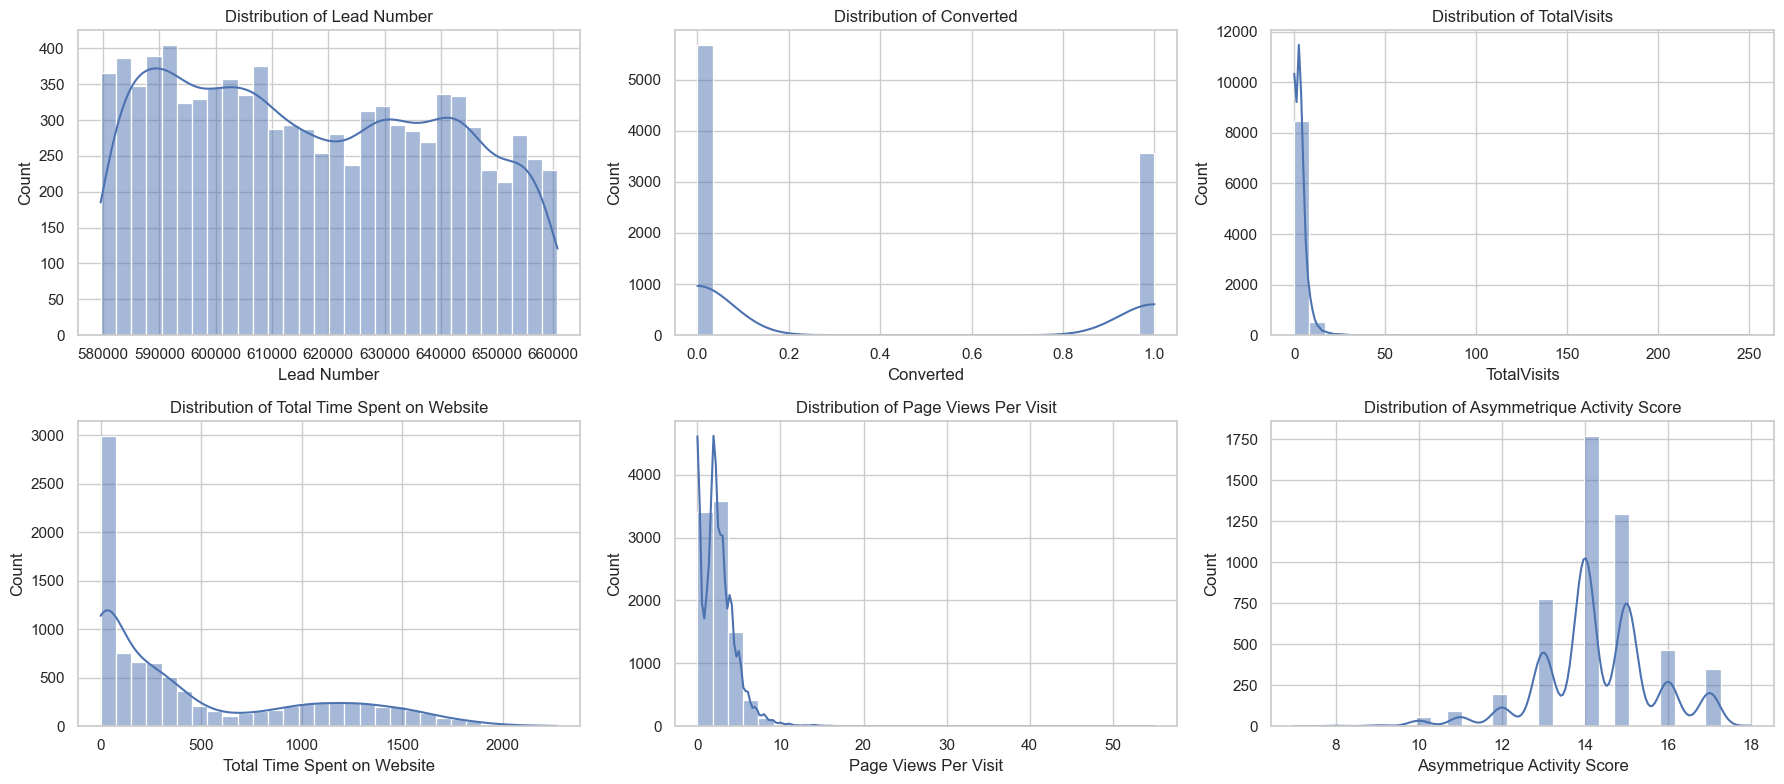

In [39]:
def plot_histograms(df, max_plots=6):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import math

    sns.set(style="whitegrid")
    numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    num_cols = numerical[:max_plots]
    rows = math.ceil(len(num_cols) / 3)

    fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
    for i, col in enumerate(num_cols):
        ax = axes[i // 3, i % 3]
        sns.histplot(df[col].dropna(), kde=True, bins=30, ax=ax)
        ax.set_title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
plot_histograms(df)

### 2.1.2: Boxplots

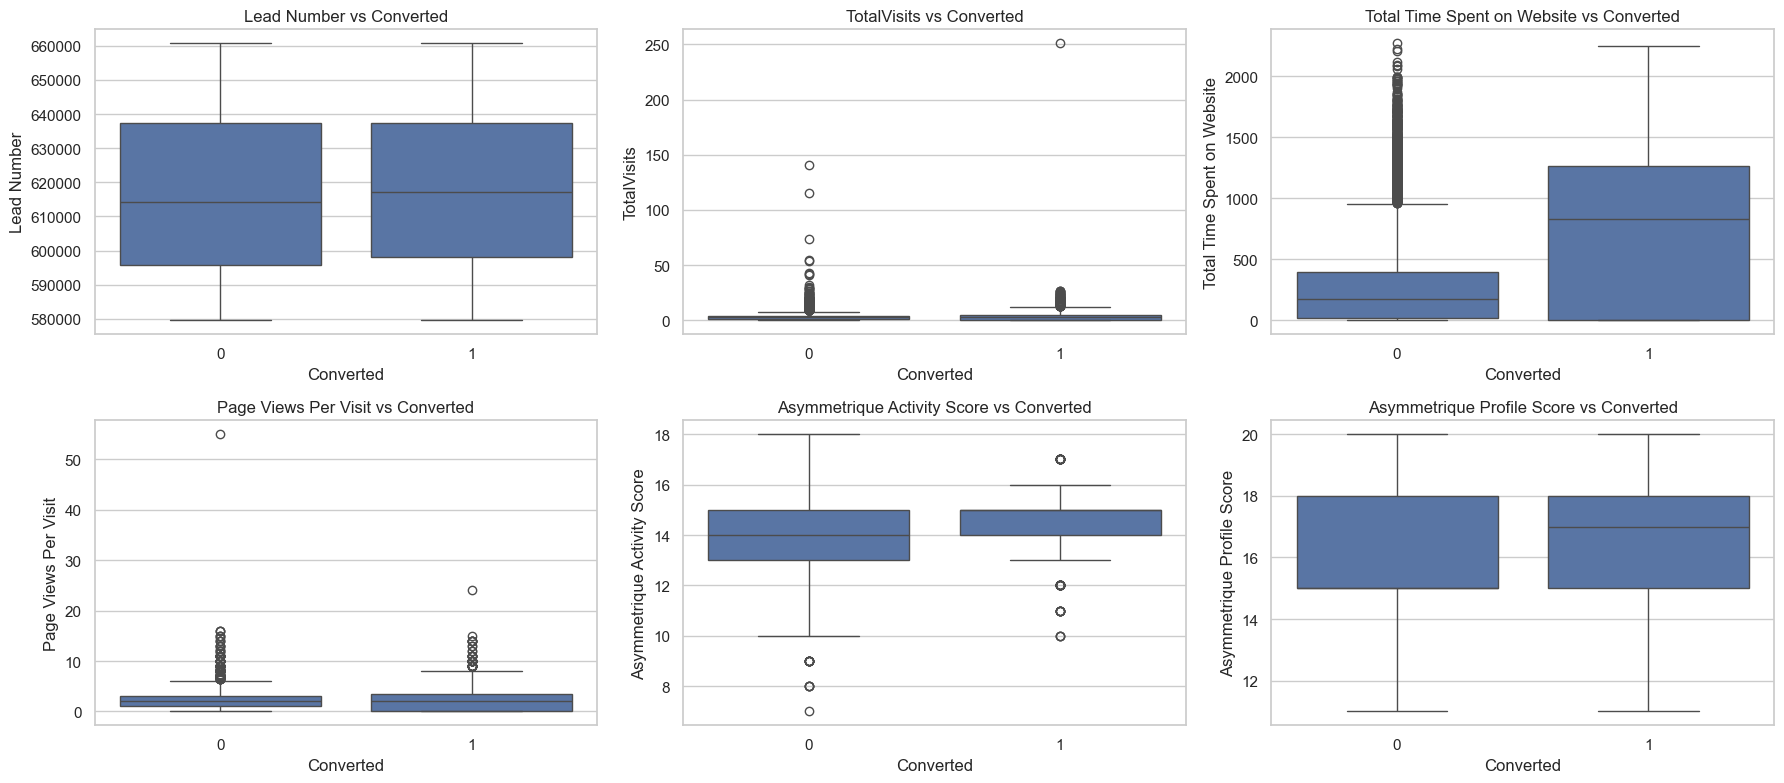

In [42]:
def plot_boxplots(df, target_col='Converted', max_plots=6):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import math

    sns.set(style="whitegrid")
    numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if target_col in numerical:
        numerical.remove(target_col)
    num_cols = numerical[:max_plots]
    rows = math.ceil(len(num_cols) / 3)

    fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
    for i, col in enumerate(num_cols):
        ax = axes[i // 3, i % 3]
        sns.boxplot(x=target_col, y=col, data=df, ax=ax)
        ax.set_title(f'{col} vs {target_col}')
    plt.tight_layout()
    plt.show()
plot_boxplots(df)

### 2.1.3: Heatmap

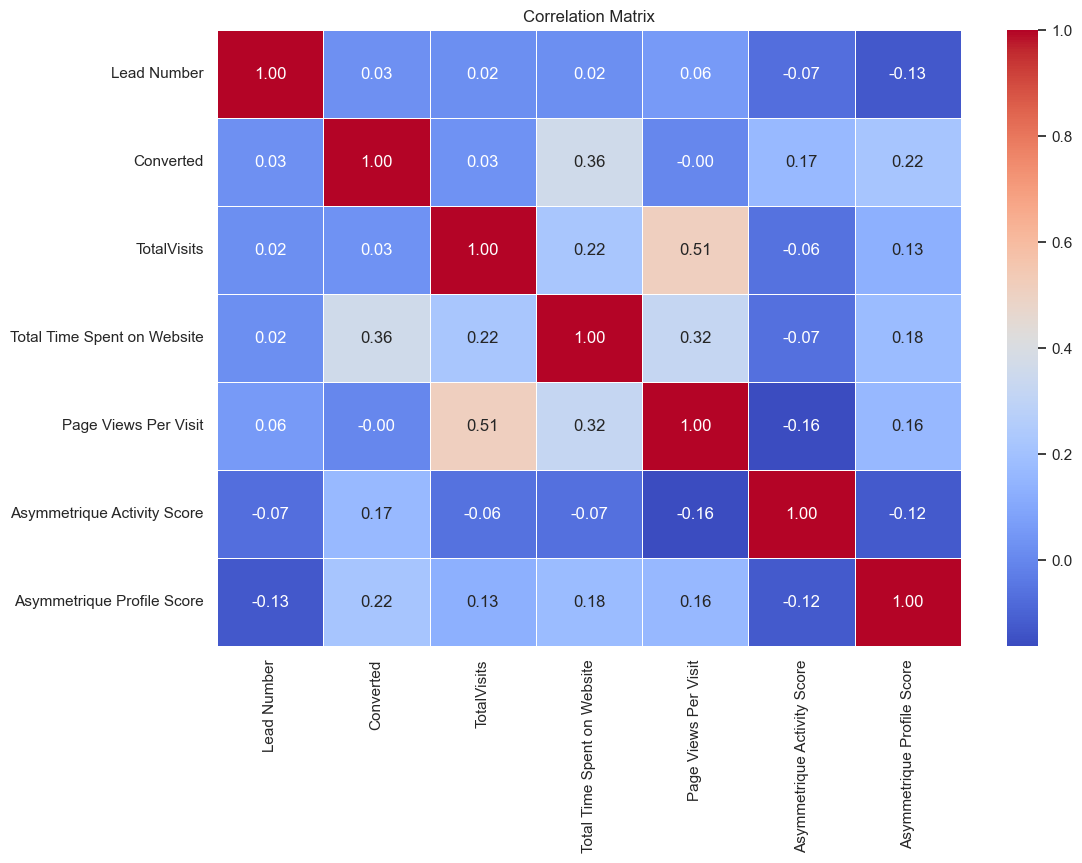

In [45]:
def plot_correlation_heatmap(df):
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 8))
    corr = df.select_dtypes(include='number').corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.show()
plot_correlation_heatmap(df)

### 2.1.4: Scatterplot

📈 Scatter Plots against `Converted`


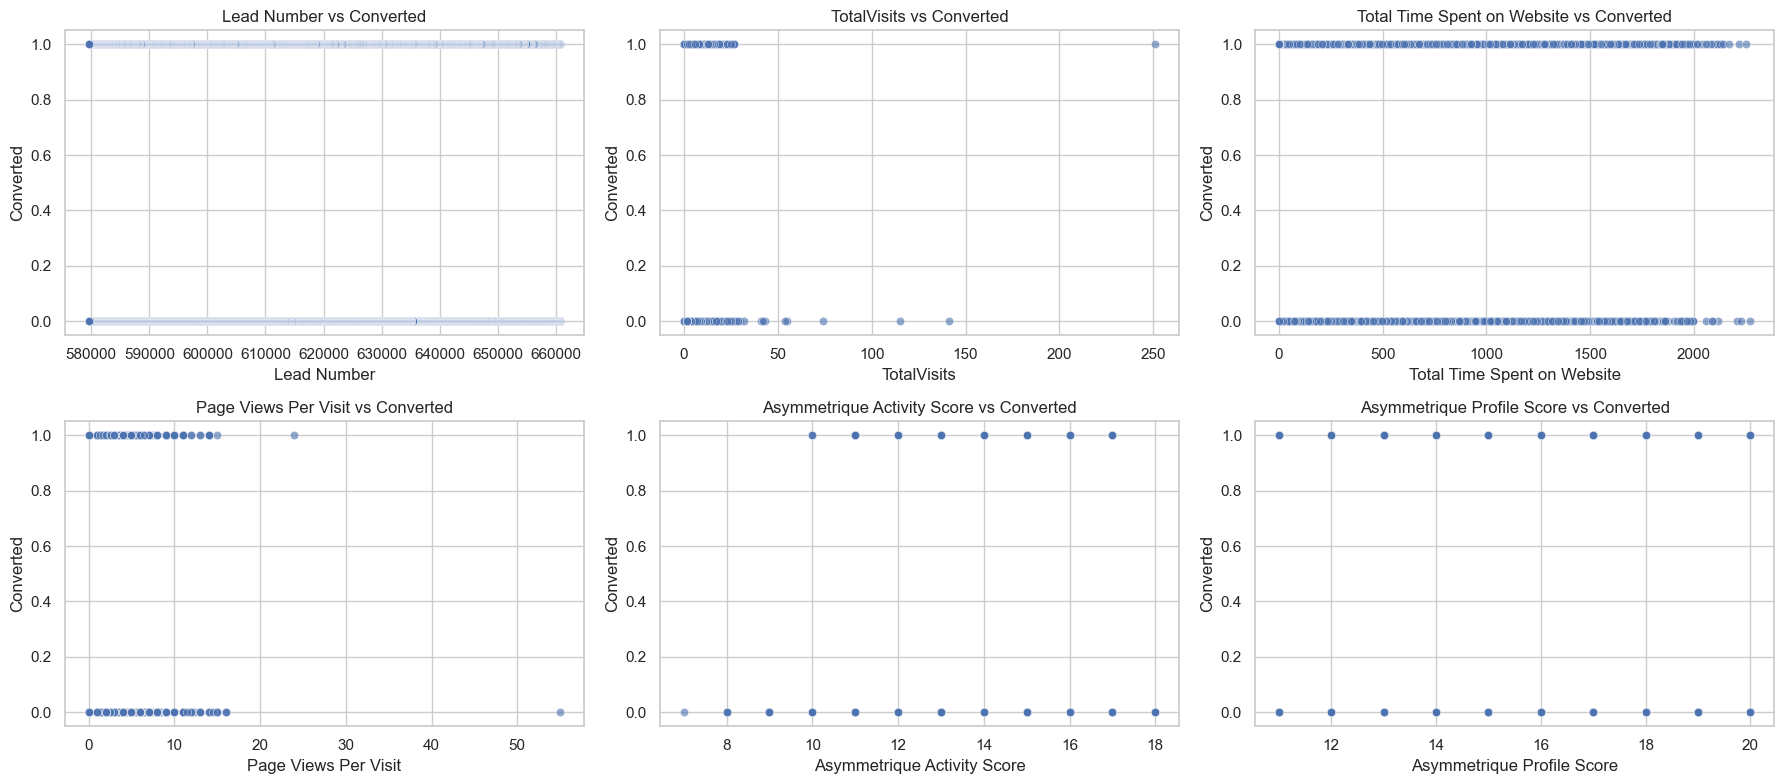

In [48]:
def plot_scatterplots(df, target_col='Converted', max_plots=6):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import math

    sns.set(style="whitegrid")

    # Filter numeric features except the target
    numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if target_col in numerical:
        numerical.remove(target_col)

    num_cols = numerical[:max_plots]
    rows = math.ceil(len(num_cols) / 3)

    print(f"📈 Scatter Plots against `{target_col}`")
    fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))

    for i, col in enumerate(num_cols):
        ax = axes[i // 3, i % 3]
        sns.scatterplot(data=df, x=col, y=target_col, alpha=0.6, ax=ax)
        ax.set_title(f'{col} vs {target_col}')
    
    plt.tight_layout()
    plt.show()
plot_scatterplots(df)

## 2.2: Categorical Features

### 2.2.1: Barplot

### 2.2.2: Histograms

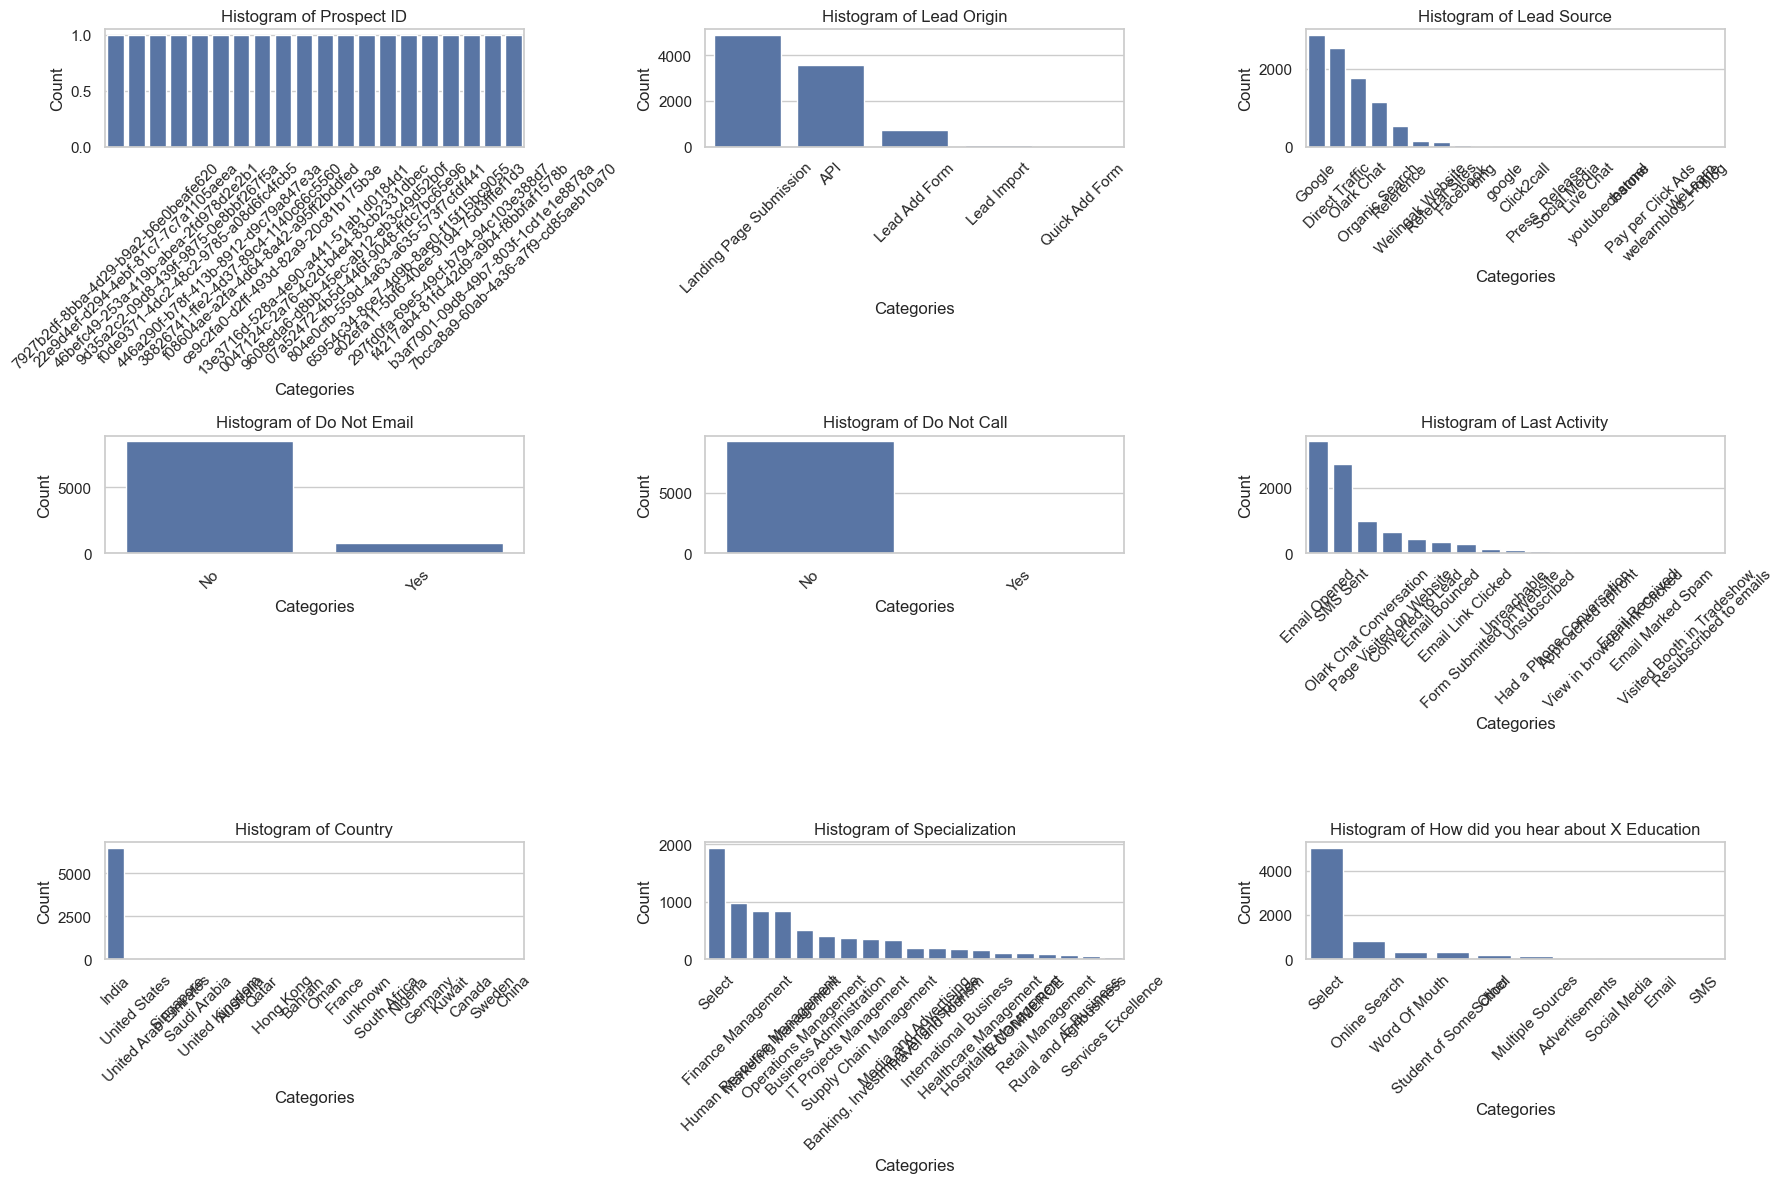

In [53]:
def plot_categorical_histograms(df, max_plots=9):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import math

    sns.set(style="whitegrid")
    
    
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    cols = cat_cols[:max_plots]
    rows = math.ceil(len(cols) / 3)

    fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        try:
            value_counts = df[col].value_counts().nlargest(20)  # top 20 for readability
            sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[i])
            axes[i].set_title(f'Histogram of {col}')
            axes[i].set_ylabel("Count")
            axes[i].set_xlabel("Categories")
            axes[i].tick_params(axis='x', rotation=45)
        except Exception as e:
            axes[i].text(0.5, 0.5, f'Error plotting {col}\n{str(e)}', ha='center')
            axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
plot_categorical_histograms(df)

# SECTION 3: DATA PREPARATION


## 3.1: Univariate Analysis

In [57]:
num_cols = df.select_dtypes(include=np.number).columns

print("\nUnivariate Analysis:\n")
df[num_cols].describe()



Univariate Analysis:



,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


## 3.2: Binary Data Analysis

In [60]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
print("Binary Features:", binary_cols)

# Define the encoding dictionary
activity_index_map = {
    '01.High': 3,
    '02.Medium': 2,
    '03.Low': 1
}

# Apply the encoding
df['Asymmetrique Activity Index'] = df['Asymmetrique Activity Index'].map(activity_index_map)
df['Asymmetrique Profile Index'] = df['Asymmetrique Profile Index'].map(activity_index_map)


binary_cats = ['Do Not Email','Do Not Call','Search','Magazine','Newspaper Article',
               'X Education Forums','Newspaper','Digital Advertisement','Through Recommendations',
               'Receive More Updates About Our Courses', 'Update me on Supply Chain Content','Get updates on DM Content',
               'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview']

null_values = df[binary_cats].isnull().sum()
total = df[binary_cats].count()
yes_no = df[binary_cats].applymap(lambda x: 1 if x == 'Yes' or x == 'No' else 0).sum()
df_binary_cats = pd.DataFrame({'total': total,
                               'null_%': null_values/total*100,
                               'yes/no_%': yes_no/total*100})
df_binary_cats

Binary Features: ['Do Not Email', 'Do Not Call', 'Converted', 'Search', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'A free copy of Mastering The Interview']


,total,null_%,yes/no_%
Do Not Email,9240,0.0,100.0
Do Not Call,9240,0.0,100.0
Search,9240,0.0,100.0
Magazine,9240,0.0,100.0
Newspaper Article,9240,0.0,100.0
X Education Forums,9240,0.0,100.0
Newspaper,9240,0.0,100.0
Digital Advertisement,9240,0.0,100.0
Through Recommendations,9240,0.0,100.0
Receive More Updates About Our Courses,9240,0.0,100.0


## 3.3: Value Count Analysis

In [63]:
from sklearn.preprocessing import FunctionTransformer

def data_cleaning(df):
    df = df.copy()
    
    # Drop ID columns if they exist
    for col in ['Prospect ID', 'Lead Number']:
        if col in df.columns:
            df = df.drop(col, axis=1)
    
    # Define binary categorical columns - make sure this list is defined before
    # e.g. binary_cats = ['some_binary_col1', 'some_binary_col2']
    if 'binary_cats' in globals():
        for col in binary_cats:
            if col in df.columns:
                df[col] = df[col].map(lambda x: 0 if x == 'No' else 1)
    
    # Rename columns for easier handling
    df.columns = df.columns.str.replace(' ', '_').str.lower()
    
    return df

# Wrap the function as transformer
initial_clean = FunctionTransformer(data_cleaning)

# Example of usage:
df_clean = initial_clean.fit_transform(df)


In [65]:
def value_counts_feature(df):
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        print(df[col].value_counts())
        print('***')
value_counts_feature(df)   

Prospect ID
7927b2df-8bba-4d29-b9a2-b6e0beafe620    1
22e9d4ef-d294-4ebf-81c7-7c7a1105aeea    1
46befc49-253a-419b-abea-2fd978d2e2b1    1
9d35a2c2-09d8-439f-9875-0e8bbf267f5a    1
f0de9371-4dc2-48c2-9785-a08d6fc4fcb5    1
                                       ..
ff1f7582-cb7b-4b94-9cdc-3d0d0afdd9a3    1
644099a2-3da4-4d23-9546-7676340a372b    1
2a093175-415b-4321-9e69-ed8d9df65a3c    1
c66249a3-8500-4c66-a511-312d914573de    1
571b5c8e-a5b2-4d57-8574-f2ffb06fdeff    1
Name: count, Length: 9240, dtype: int64
***
Lead Origin
Landing Page Submission    4886
API                        3580
Lead Add Form               718
Lead Import                  55
Quick Add Form                1
Name: count, dtype: int64
***
Lead Source
Google               2868
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Reference             534
Welingak Website      142
Referral Sites        125
Facebook               55
bing                    6
google                  5
Click2ca

## 3.4: Missing Value Analysis

In [68]:
### Explore missing values

import seaborn as sns
import matplotlib.pyplot as plt
df_ = df_clean.copy()

# Set style for better visualizations
sns.set_style('dark')
sns.set(rc={'axes.grid':False})
sns.set_palette('viridis')

null_ = pd.DataFrame()
null_['proportion'] = np.round(df_clean.isnull().sum()/len(df_clean),4) * 100
null_['amount'] = df_clean.isnull().sum()

# Show only those columns with at least 1 missing value
null_.sort_values(by='proportion', ascending=False)[null_.amount >= 0]

,proportion,amount
lead_quality,51.59,4767
asymmetrique_activity_index,45.65,4218
asymmetrique_profile_score,45.65,4218
asymmetrique_profile_index,45.65,4218
asymmetrique_activity_score,45.65,4218
tags,36.29,3353
lead_profile,29.32,2709
what_matters_most_to_you_in_choosing_a_course,29.32,2709
what_is_your_current_occupation,29.11,2690
country,26.63,2461


In [70]:
def barplot_catcols(column,width,heigh):
  """Plot conversion rate"""
  fig, ax  = plt.subplots(figsize=(width,heigh))
  ax = sns.barplot(data=df_.fillna('NaN'), x='converted', y=column,
            order=order(df_.fillna('NaN'),column),
            orient='h', palette='viridis',
            seed=2)
  plt.title(f'Conversion Rate by {column.replace("_"," ").title()}', loc='left', size=18)
  return ax

def order(df,x,y=None):
    if y is not None:
        return df.groupby(x)[y].mean().sort_values(ascending=False).index
    else:
        return df.groupby(x)['converted'].mean().sort_values(ascending=False).index

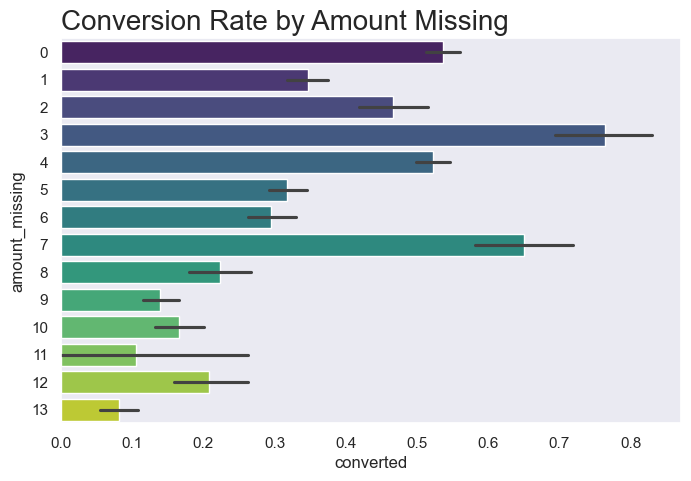

In [72]:
# Number of missing values in each row
df_['amount_missing'] = df_.isnull().sum(1)

# Plot the relation between amount missing and conversion rate
fig, ax  = plt.subplots(figsize=(8,5))
ax = sns.barplot(data=df_.fillna('NaN'), x='converted', y='amount_missing',
            orient='h', palette='viridis',
            seed=2)
plt.title(f'Conversion Rate by Amount Missing', loc='left', size=20)
plt.show()

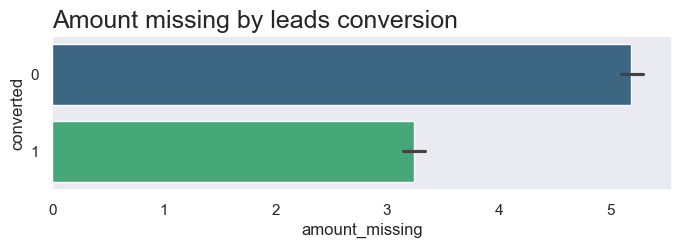

In [74]:
fig, ax  = plt.subplots(figsize=(8,2))
ax = sns.barplot(data=df_, x='amount_missing', y='converted',
            orient='h', palette=sns.color_palette('viridis',2),
            seed=2)
plt.title(f'Amount missing by leads conversion', loc='left', size=18)
plt.show()


## 3.4: Correlation with target variable

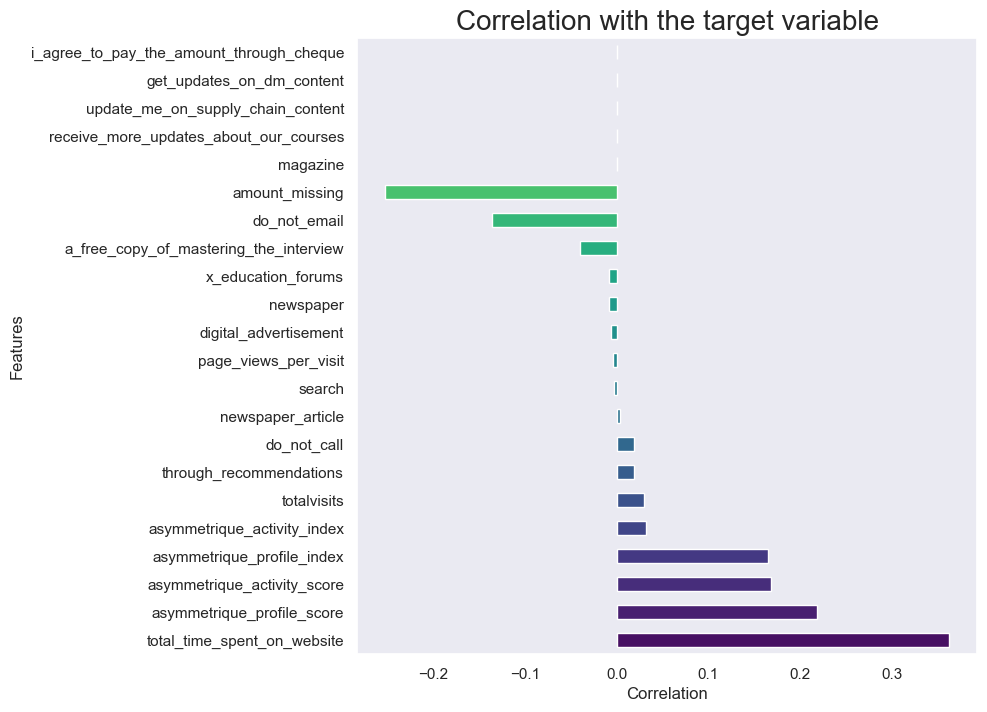

In [77]:
correlations = df_.select_dtypes('number').corr()['converted'].sort_values(ascending=False)

plt.figure(figsize=(8, 8))
correlations[1:].plot(kind='barh', 
                 color=sns.color_palette('viridis', len(correlations)))

plt.title('Correlation with the target variable', fontsize=20)
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.show()

### 3.4.1: Insights of Data

There's a negative correlation between missing lead data and the conversion rate. Higher instances of missing data might signify incomplete or poorly managed lead information, leading to potential difficulties in accurately categorizing and nurturing leads.

Notably, there's one column, **"Total Time Spent On Website,"** which has a stronger correlation with the target variable than the number of missing values columns. This suggests that it might be a better potential predictor than most of the other features.


In [80]:
print(f'Duplicate rows from original dataset: {df.duplicated().sum()}')
print(f'Duplicate rows after feature engineer: {df_clean.duplicated().sum()}')


Duplicate rows from original dataset: 0
Duplicate rows after feature engineer: 1281


## 3.5: Target Variable Analysis

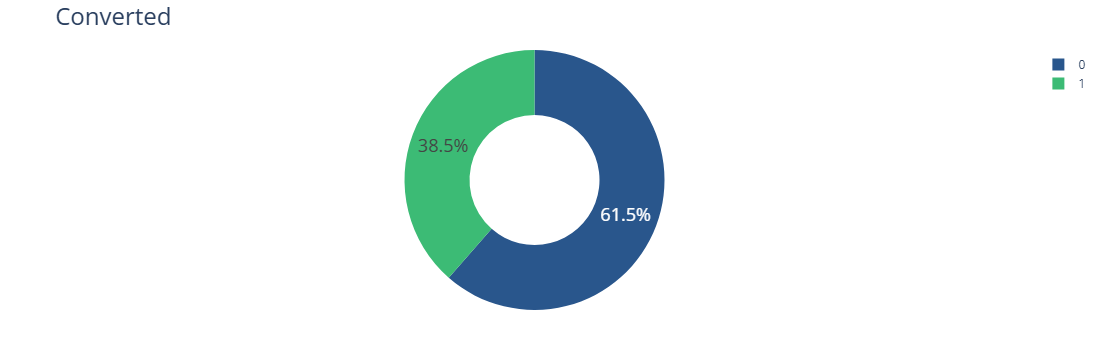

In [83]:
import plotly.graph_objects as go

# Count data
count = df_['converted'].value_counts()

# Create a 3D-like pie chart (donut style)
fig = go.Figure(go.Pie(
    labels=count.index,
    values=count.values,
    hole=0.5,  # Makes it a donut
    marker=dict(colors=['#29568CFF', '#3CBB75FF']),
    hoverinfo='label+percent+value',
    textinfo='percent',
    textfont_size=18
))

fig.update_layout(
    title_text='Converted',
    title_font_size=24,
    showlegend=True,
    margin=dict(t=50, b=50, l=50, r=50)
)

# Show the chart
fig.show()


## 3.6: Comparison of Feature with Conversion Rate

### 3.6.1: Conversion Rate by Lead Profile

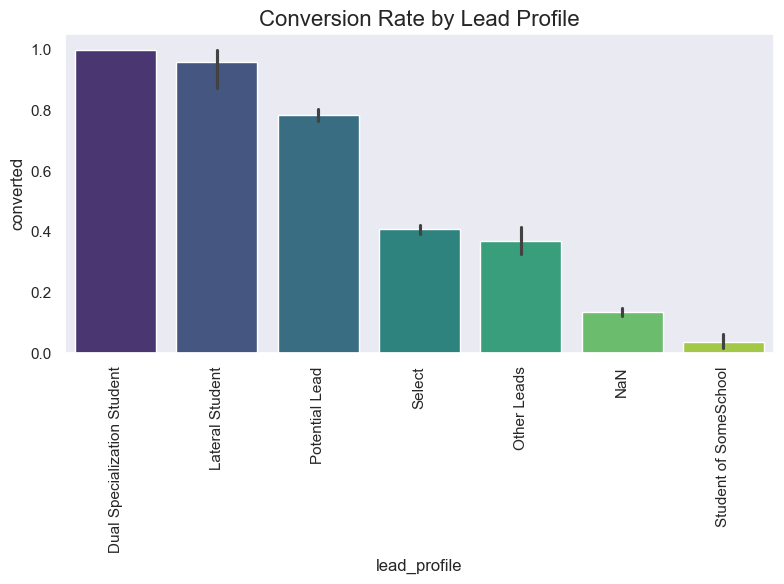

In [87]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df_.fillna('NaN'), x='lead_profile', y='converted',
            palette='viridis', order=order(df_.fillna('NaN'),'lead_profile'),
            seed=2)

plt.xticks(rotation=90)
plt.title(f'Conversion Rate by Lead Profile', loc='center', size=16)

plt.tight_layout()
plt.show()

In [89]:
#Lead Activity

In [91]:
activity_columns = ['totalvisits','total_time_spent_on_website','page_views_per_visit']

df_[activity_columns].corr().style.background_gradient(cmap='vlag_r')

,totalvisits,total_time_spent_on_website,page_views_per_visit
totalvisits,1.000000,0.221240,0.512125
total_time_spent_on_website,0.221240,1.000000,0.320361
page_views_per_visit,0.512125,0.320361,1.000000


### 3.6.2: Conversion Rate by Last Activity and Last Notable Activity

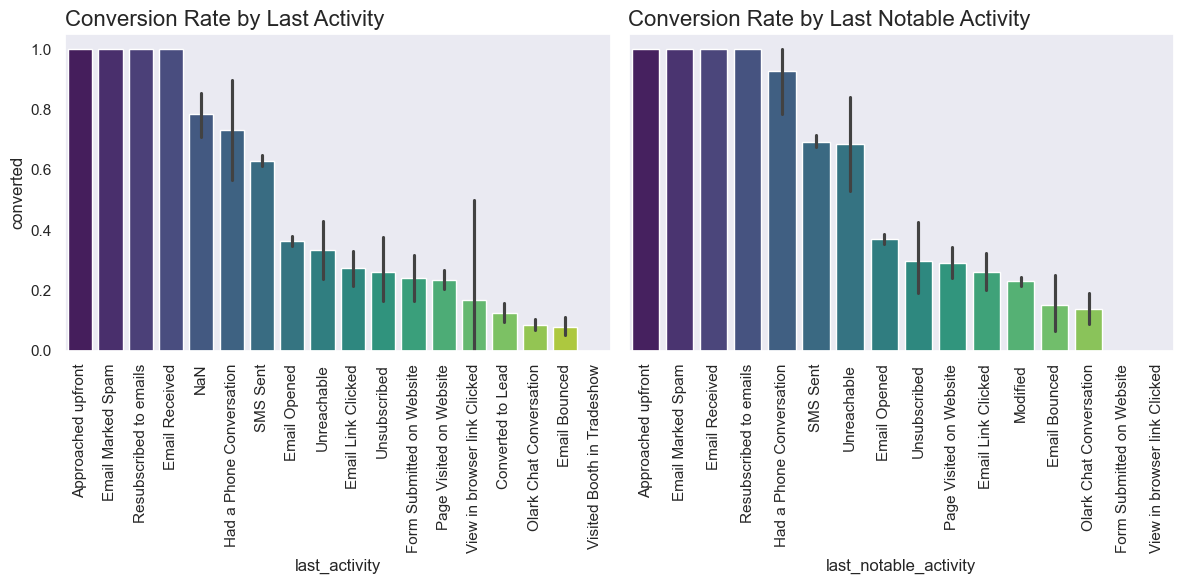

In [94]:
fig, ax  = plt.subplots(1,2, figsize=(12,6), sharey=True)

sns.barplot(data=df_.fillna('NaN'), x='last_activity', y='converted',
            order=order(df_.fillna('NaN'),'last_activity'),
            palette='viridis',
            seed=2, ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
ax[0].set_title(f'Conversion Rate by Last Activity', loc='left', size=16)

sns.barplot(data=df_.fillna('NaN'), x='last_notable_activity', y='converted',
                  order=order(df_.fillna('NaN'),'last_notable_activity'),
                  palette='viridis', seed=2)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
ax[1].set_title(f'Conversion Rate by Last Notable Activity', loc='left', size=16)

plt.tight_layout()
plt.show()

### 3.6.3: Conversion Rate by Lead Quality

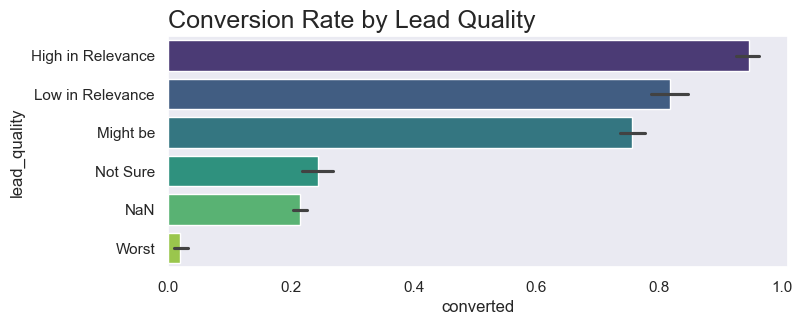

<Figure size 640x480 with 0 Axes>

In [97]:
barplot_catcols('lead_quality',8,3)
plt.show()
plt.savefig('lead_quality.png')


### 3.6.4: Conversion Type by Tags

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\human1\\Documents\\HFU\\DSResources\\tags.png'

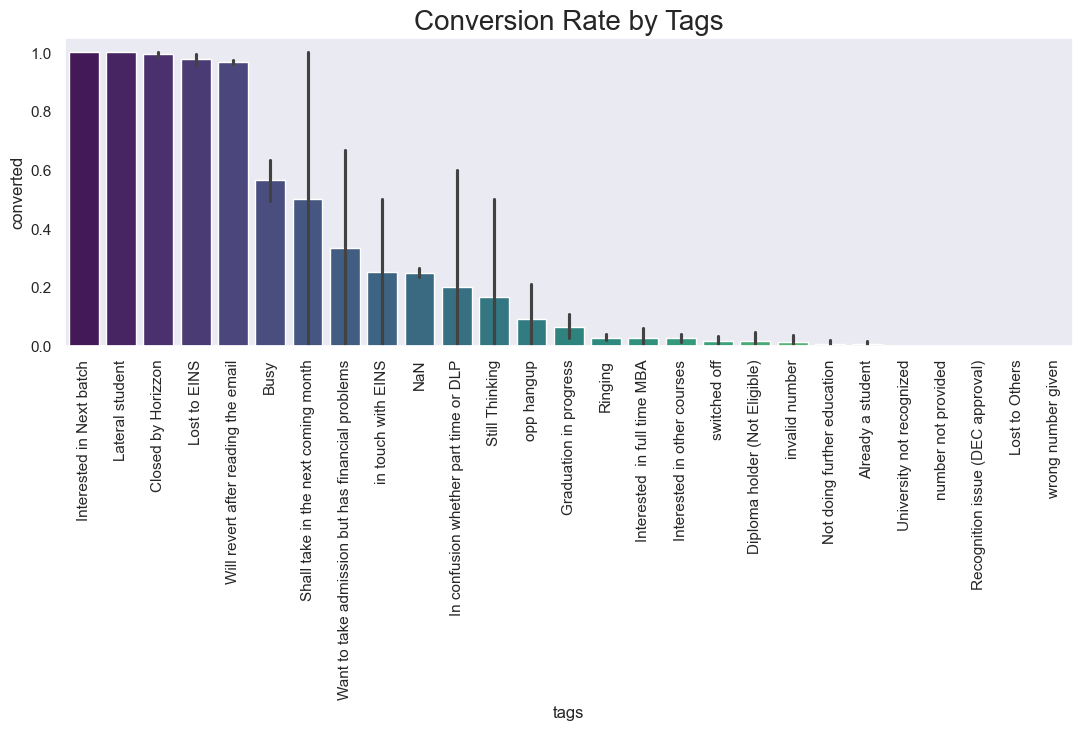

In [102]:
fig, ax  = plt.subplots(figsize=(13,4))

sns.barplot(data=df_.fillna('NaN'), x='tags', y='converted',
            order=order(df_.fillna('NaN'),'tags'),
            palette='viridis',
            seed=2)
plt.xticks(rotation=90)
plt.title(f'Conversion Rate by Tags', loc='center', size=20)
plt.savefig('/Users/human1/Documents/HFU/DSResources/tags.png', bbox_inches='tight')

plt.show()


### 3.6.5: Conversion Type by Specilization and Occupation

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\human1\\Documents\\HFU\\DSResources\\specialization_occupation.png'

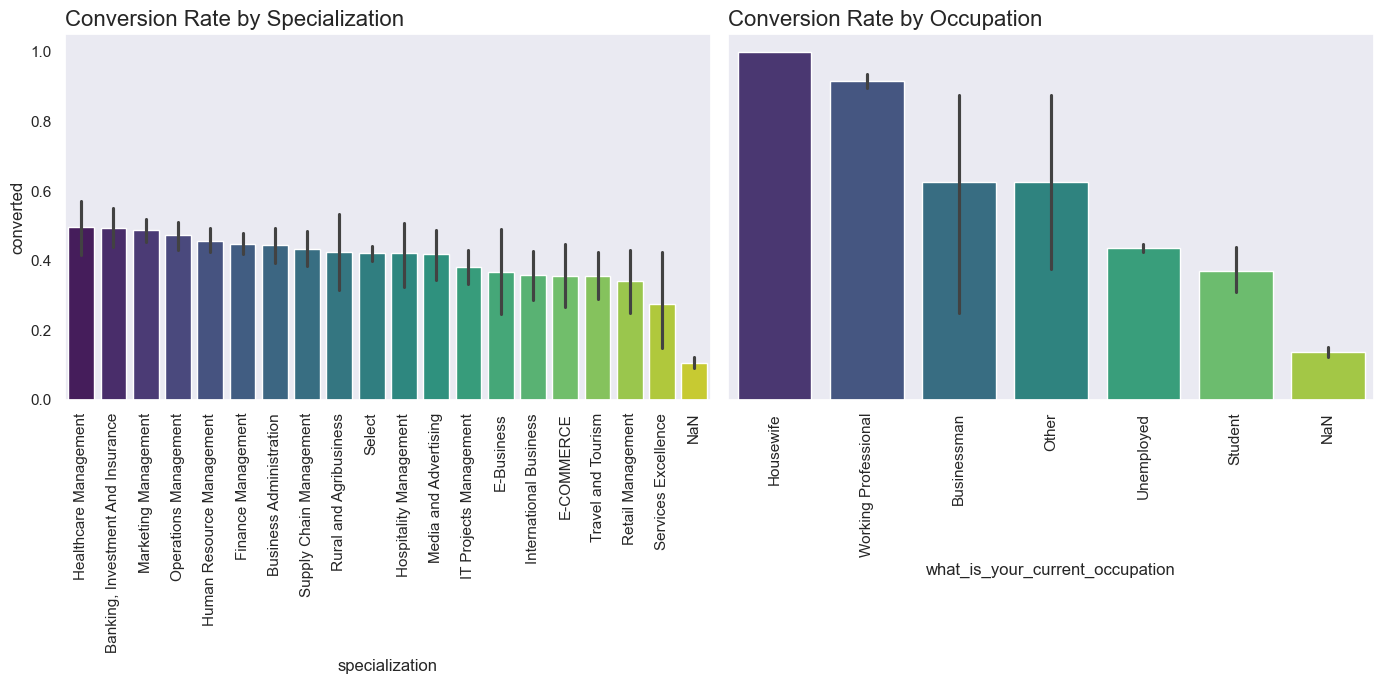

In [105]:
fig, ax  = plt.subplots(1,2, figsize=(14,7), sharey=True)

sns.barplot(data=df_.fillna('NaN'), x='specialization', y='converted',
            order=order(df_.fillna('NaN'),'specialization'),
            palette='viridis',
            seed=2, ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
ax[0].set_title(f'Conversion Rate by Specialization', loc='left', size=16)

sns.barplot(data=df_.fillna('NaN'), x='what_is_your_current_occupation', y='converted',
                  order=order(df_.fillna('NaN'),'what_is_your_current_occupation'),
                  palette='viridis', seed=2)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
ax[1].set_title(f'Conversion Rate by Occupation', loc='left', size=16)

plt.tight_layout()
plt.savefig('/Users/human1/Documents/HFU/DSResources/specialization_occupation.png', bbox_inches='tight')

plt.show()

### 3.6.4: Conversion Type by Tags

In [108]:
conversion_country = df_.groupby('country')['converted'].mean()
country_count = df_['country'].value_counts().sort_index()
country_count

country
Asia/Pacific Region        2
Australia                 13
Bahrain                    7
Bangladesh                 2
Belgium                    2
Canada                     4
China                      2
Denmark                    1
France                     6
Germany                    4
Ghana                      2
Hong Kong                  7
India                   6492
Indonesia                  1
Italy                      2
Kenya                      1
Kuwait                     4
Liberia                    1
Malaysia                   1
Netherlands                2
Nigeria                    4
Oman                       6
Philippines                2
Qatar                     10
Russia                     1
Saudi Arabia              21
Singapore                 24
South Africa               4
Sri Lanka                  1
Sweden                     3
Switzerland                1
Tanzania                   1
Uganda                     2
United Arab Emirates      53
United

### 3.6.5: Conversion Type by Country

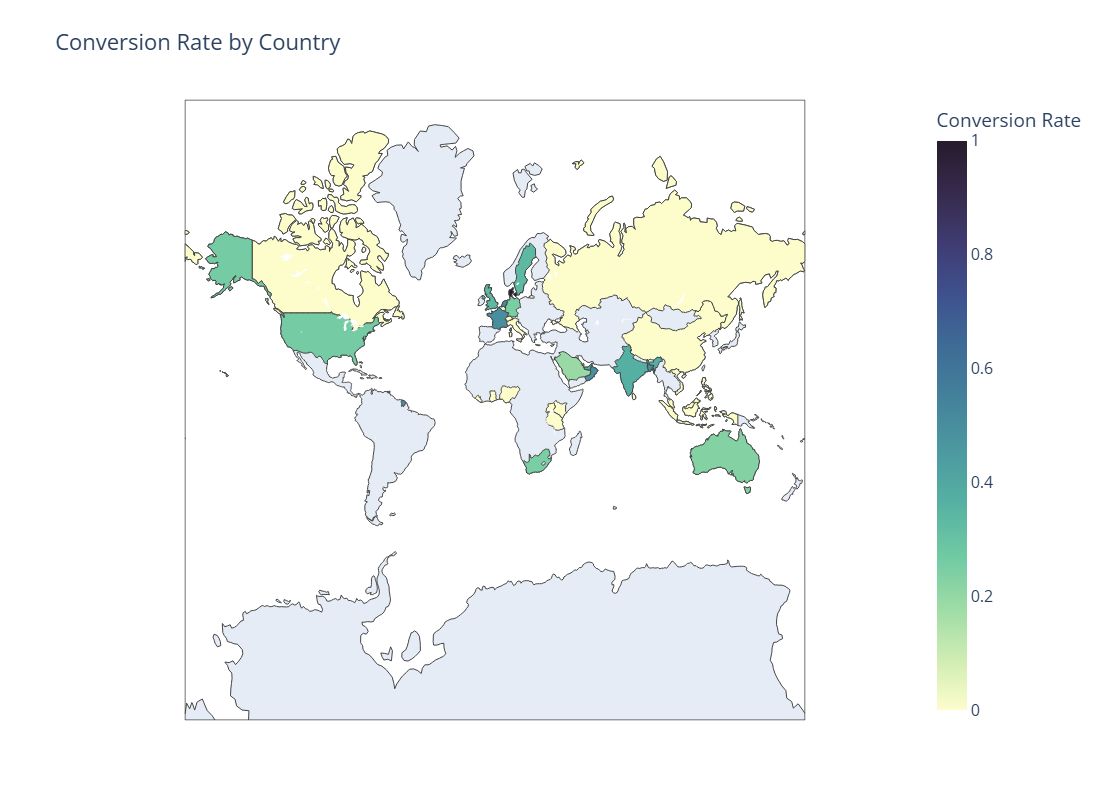

In [111]:
import plotly.graph_objects as go


fig = go.Figure(data=go.Choropleth(
    locations=conversion_country.index,
    locationmode='country names',
    z=conversion_country.values,
    text=country_count.values,
    colorscale='deep', 
    colorbar_title='Conversion Rate',
    hovertemplate='%{location}<br>Conversion: %{z:.2f}<br>Count: %{text}',
))

fig.update_geos(projection_type="mercator")

fig.update_layout(
    width=1000,   # in pixels
    height=800,

    title='Conversion Rate by Country',
    geo=dict(showcoastlines=True),
    font=dict(size=16),
)



fig.show()

### 3.6.6: Conversion Type by City

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\human1\\Documents\\HFU\\DSResources\\city.png'

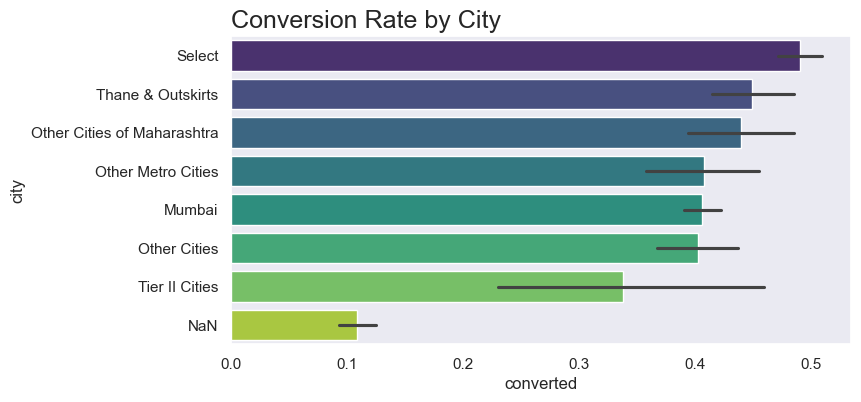

In [114]:
barplot_catcols('city',8,4)
plt.savefig('/Users/human1/Documents/HFU/DSResources/city.png', bbox_inches='tight')


plt.show()


In [116]:
print("Cities where country isn't India:")
df_[df_['country'] != 'India'].city.value_counts(dropna=False)

Cities where country isn't India:


city
Select                         1250
NaN                             865
Mumbai                          304
Other Cities                    122
Thane & Outskirts               101
Other Cities of Maharashtra      66
Other Metro Cities               35
Tier II Cities                    5
Name: count, dtype: int64

In [118]:
print('Countries where City as equal to an Indian city:')
indian_cities = ['Mumbai','Thane & Outskirts','Other Cities of Maharashtra','Tier II Cities']
df_[df_.city.isin(indian_cities)].country.value_counts(dropna=False)

Countries where City as equal to an Indian city:


country
India                   4029
NaN                      336
United States             41
United Arab Emirates      21
United Kingdom            11
Singapore                 11
Saudi Arabia              10
Australia                  9
Bahrain                    5
Qatar                      5
Hong Kong                  4
Canada                     3
Germany                    3
Belgium                    2
France                     2
Oman                       2
Kuwait                     2
Netherlands                2
China                      1
Sweden                     1
Malaysia                   1
Switzerland                1
Philippines                1
Vietnam                    1
Indonesia                  1
Name: count, dtype: int64

1️⃣ Fix City-Country Mismatch:
Update the country to “India” for cities:

Mumbai

Thane & Outskirts

Other Cities of Maharashtra

Tier II Cities

2️⃣ Group Rare Countries:
Keep top 5 countries; group the rest as “Other”.

3️⃣ Handle Missing City Data:
Flag rows with missing city values due to lower conversion rates.`

### 3.6.7: Conversion Type by Lead Source & How did you hear about us?

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\human1\\Documents\\HFU\\DSResources\\lead_source&hear_about_us.png'

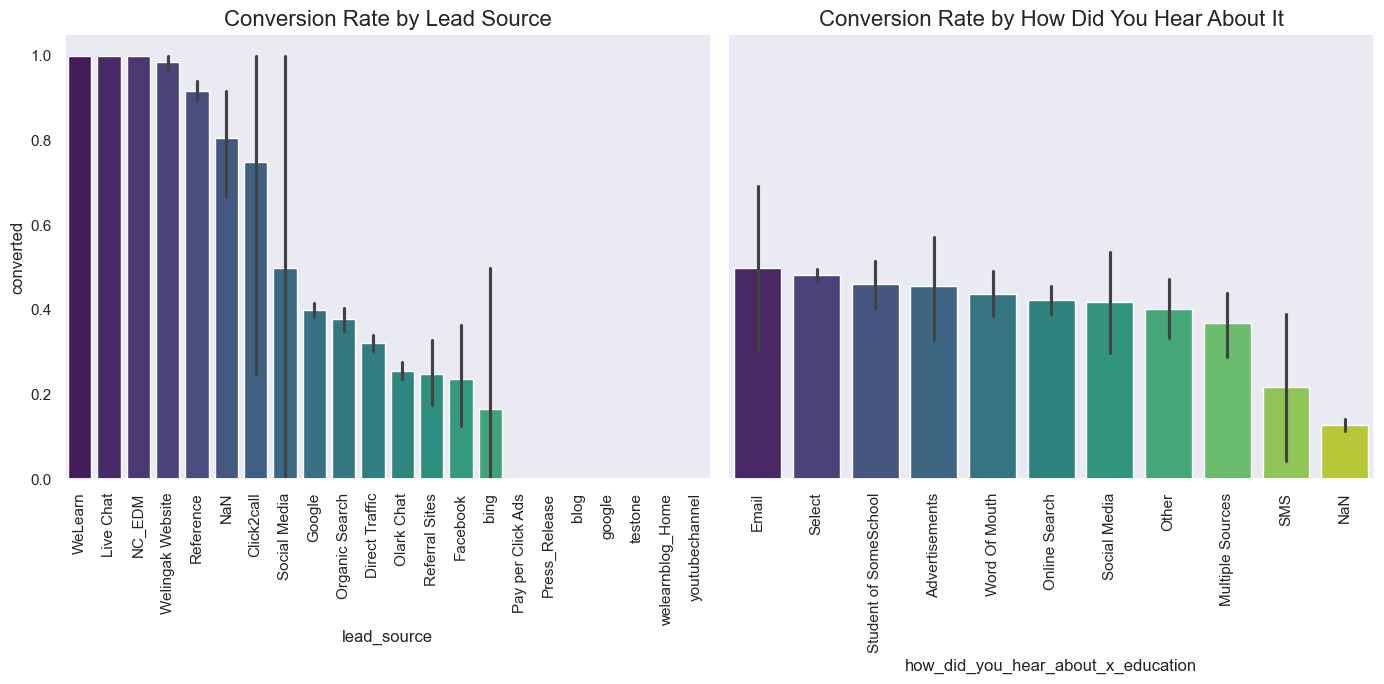

In [122]:
fig, ax  = plt.subplots(1,2, figsize=(14,7), sharey=True)

sns.barplot(data=df_.fillna('NaN'), x='lead_source', y='converted',
            order=order(df_.fillna('NaN'),'lead_source'),
            palette='viridis',
            seed=2, ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
ax[0].set_title(f'Conversion Rate by Lead Source', loc='center', size=16)

sns.barplot(data=df_.fillna('NaN'), x='how_did_you_hear_about_x_education', y='converted',
                  order=order(df_.fillna('NaN'),'how_did_you_hear_about_x_education'),
                  palette='viridis', seed=2)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
ax[1].set_title(f'Conversion Rate by How Did You Hear About It', loc='center', size=16)

plt.tight_layout()
plt.savefig('/Users/human1/Documents/HFU/DSResources/lead_source&hear_about_us.png', bbox_inches='tight')

plt.show()

## 3.7: Numerical Values Analysis

In [ ]:
df_.select_dtypes(include=['number'])

#This gives all the features with numerical values


In [125]:
#We have 21 numerical columns
print(df_.select_dtypes(include=['number']).shape)

(9240, 23)


Data Manipulation:
Almost all the numerical columns in the dataset represent binary outputs. But here's the catch: the vast majority of these columns have only one value, which is 0. That means they don't really offer any meaningful information to the model, and they're just cluttering up the dataset. Thus, it would be wise to drop these columns to improve model performance and reduce unnecessary noise in the data.

## 3.8: Time spent on page

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\human1\\Documents\\HFU\\DSResources\\all_activities.png'

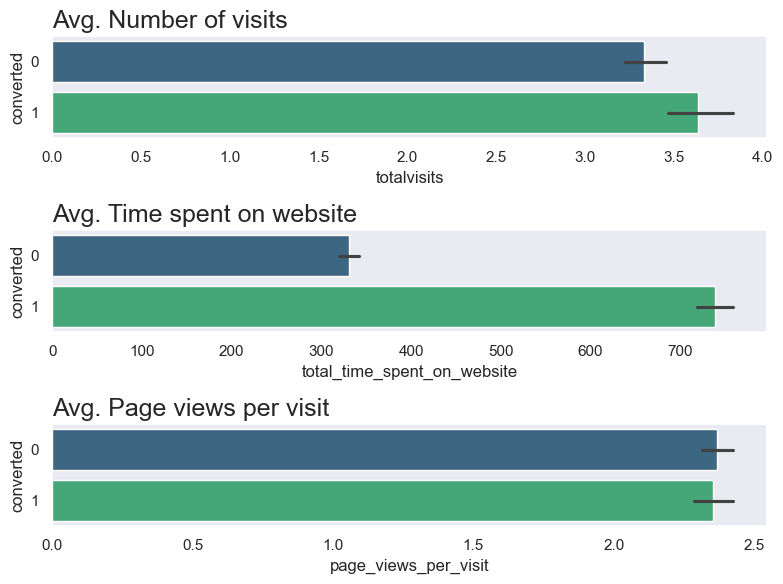

In [129]:
fig, ax  = plt.subplots(3, figsize=(8,6))
sns.barplot(data=df_, x='totalvisits', y='converted',
            orient='h', palette='viridis',
            seed=2, ax=ax[0])
ax[0].set_title(f'Avg. Number of visits', loc='left', size=18)

sns.barplot(data=df_, x='total_time_spent_on_website', y='converted',
            orient='h', palette='viridis',
            seed=2, ax=ax[1])
ax[1].set_title(f'Avg. Time spent on website', loc='left', size=18)

sns.barplot(data=df_, x='page_views_per_visit', y='converted',
            orient='h', palette='viridis',
            seed=2, ax=ax[2])
ax[2].set_title(f'Avg. Page views per visit', loc='left', size=18)

plt.tight_layout()
plt.savefig('/Users/human1/Documents/HFU/DSResources/all_activities.png', bbox_inches='tight')

plt.show()

In [ ]:
fig, ax = plt.subplots(3,1, figsize=(8,6))
sns.boxplot(data=df_, x='totalvisits',
              ax=ax[0], palette='viridis')
ax[0].set_title('Total Visits', loc='left', size=16)

sns.boxplot(data=df_, x='total_time_spent_on_website',
              ax=ax[1], palette='viridis')
ax[1].set_title('Time spent on web', loc='left', size=16)

sns.boxplot(data=df_, x='page_views_per_visit',
              ax=ax[2], palette='viridis')
ax[2].set_title('Page views per visit', loc='left', size=16)

plt.tight_layout()
plt.savefig('/Users/human1/Documents/HFU/DSResources/visits_box_plot.png', bbox_inches='tight')

plt.show()


###KNN Imputation for numerical values

How it works:
For each missing value:

It identifies the K most similar rows (neighbors) that don’t have missing values in that column.

It estimates the missing value by averaging (or using a weighted average of) the corresponding values from these neighbors.


## 3.9: Feature Engineering

In [134]:
# Filter numeric features except the target
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [136]:
numerical_columns = [
    'Lead Number',
    'Converted',
    'TotalVisits',
    'Total Time Spent on Website',
    'Page Views Per Visit',
    'Asymmetrique Activity Index',
    'Asymmetrique Profile Index',
    'Asymmetrique Activity Score',
    'Asymmetrique Profile Score'
]

categorical_columns = [
    'Prospect ID',
    'Lead Origin',
    'Lead Source',
    'Do Not Email',
    'Do Not Call',
    'Last Activity',
    'Country',
    'Specialization',
    'How did you hear about X Education',
    'What is your current occupation',
    'What matters most to you in choosing a course',
    'Search',
    'Magazine',
    'Newspaper Article',
    'X Education Forums',
    'Newspaper',
    'Digital Advertisement',
    'Through Recommendations',
    'Receive More Updates About Our Courses',
    'Tags',
    'Lead Quality',
    'Update me on Supply Chain Content',
    'Get updates on DM Content',
    'Lead Profile',
    'City',
    'I agree to pay the amount through cheque',
    'A free copy of Mastering The Interview',
    'Last Notable Activity'
]


### 3.9.1: Data Cleaning

### 3.9.2: Intial Feature Engineering

### 3.9.3: Exploratory Data Analysis

### 3.9.4: Outliers Handling

In [141]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import FunctionTransformer

## Data Cleaning

def data_cleaning(df):
    df = df.copy()
    
    # Drop ID columns if they exist
    for col in ['Prospect ID', 'Lead Number']:
        if col in df.columns:
            df = df.drop(col, axis=1)
    
    # Define binary categorical columns - make sure this list is defined before
    # e.g. binary_cats = ['some_binary_col1', 'some_binary_col2']
    if 'binary_cats' in globals():
        for col in binary_cats:
            if col in df.columns:
                df[col] = df[col].map(lambda x: 0 if x == 'No' else 1)
    
    # Rename columns for easier handling
    df.columns = df.columns.str.replace(' ', '_').str.lower()
    
    return df

# Wrap the function as transformer
initial_clean = FunctionTransformer(data_cleaning)

# Example of usage:
# df_clean = initial_clean.fit_transform(df)


#------------------- Initial Feature Engineering -------------------
def initial_feature_engineering(df):
    df = df.copy()
    
    # Lead Source
    df['Lead Source'] = df['Lead Source'].str.replace('|'.join(['google', 'Pay per Click Ads']), 'Google', regex=True)
    df['Lead Source'] = df['Lead Source'].apply(lambda x: "Referral Sites" if 'blog' in str(x).lower() else x)
    df['Lead Source'] = df['Lead Source'].str.replace('Live Chat', 'Olark Chat')
    df['Lead Source'] = df['Lead Source'].str.replace('bing', 'Organic Search')
    top_sources = df['Lead Source'].value_counts()[:8].index
    df['Lead Source'] = df['Lead Source'].apply(lambda x: "Other" if x not in top_sources else x)

    # Last Activity and Last Notable Activity
    activity = ['Last Activity', 'Last Notable Activity']
    for col in activity:
        df[col] = df[col].str.replace('|'.join(['Email Received', 'SMS Sent']), 'SMS/Email Sent', regex=True)
        df[col] = df[col].str.replace('|'.join(['Email Marked Spam', 'Email Bounced', 'Unsubscribed']), 'Not interested in email', regex=True)
        df[col] = df[col].str.replace('Resubscribed to emails', 'Email Opened')
        df[col] = df[col].str.replace('|'.join(['Visited Booth in Tradeshow', 'View in browser link Clicked']), 'Page Visited on Website', regex=True)

    # Country
    df['Country'] = df['Country'].apply(lambda x: np.nan if str(x).lower() in ['unknown', 'asia/pacific region'] else x)

    # Specialization
    df['Specialization'] = df['Specialization'].str.replace('|'.join(['E-COMMERCE', 'E-Business']), 'E-commerce', regex=True)
    df['Specialization'] = df['Specialization'].str.replace('Banking, Investment And Insurance', 'Finance Management')
    df['Specialization'] = df['Specialization'].str.replace('Media and Advertising', 'Marketing Management')
    df['Specialization'] = df['Specialization'].str.replace('Select', 'Not Provided')

    # How did you hear about X Education
    df['How did you hear about X Education'] = df['How did you hear about X Education'].str.replace('Select', 'Not Provided')
    df['How did you hear about X Education'] = df['How did you hear about X Education'].str.replace('|'.join(['SMS', 'Email']), 'SMS/Email', regex=True)

    # What matters most to you in choosing a course
    df['What matters most to you in choosing a course'] = df['What matters most to you in choosing a course'].str.replace('|'.join(['Flexibility & Convenience', 'Other']), "Better Career Prospects", regex=True)

    # Lead Profile
    df['Lead Profile'] = df['Lead Profile'].str.replace('Select', 'Not Assigned')

    # City
    df['City'] = df['City'].str.replace('Select', 'Not Provided')

    return df

# ------------------- EDA Feature Engineering -------------------
def eda_feature_engineering(df):
    df = df.copy()

    # Tags column
    df['Tags'] = df['Tags'].str.replace('|'.join(['invalid number', 'wrong number given', 'number not provided']), 'Not interest in calls', regex=True)
    df['Tags'] = df['Tags'].str.replace('|'.join(["In confusion whether part time or DLP", "Interested in Next batch", "Shall take in the next coming month", "Still Thinking"]), "Shows certain interest", regex=True)
    df['Tags'] = df['Tags'].str.replace("University not recognized", "Not elegible")
    df['Tags'] = df['Tags'].apply(lambda x: 'Not elegible' if pd.notnull(x) and 'holder' in x else x)
    df['Tags'] = df['Tags'].str.replace('|'.join(["Interested in other courses", "Interested  in full time MBA", "Not doing further education"]), "Doesn't show interest", regex=True)
    df['Tags'] = df['Tags'].str.replace('|'.join(["Ringing", "switched off"]), "Still no contact", regex=True)
    df['Tags'] = df['Tags'].str.replace('|'.join(["Want to take admission but has financial problems", "Graduation in progress"]), "Not elegible for the moment", regex=True)
    df['Tags'] = df['Tags'].apply(lambda x: 'Not elegible for the moment' if pd.notnull(x) and 'Recognition' in x else x)
    top_tags = df['Tags'].value_counts(dropna=False)[:12].index
    df['Tags'] = df['Tags'].apply(lambda x: 'Other' if x not in top_tags else x)

    # Country and City
    indian_cities = ['Mumbai', 'Thane & Outskirts', 'Other Cities of Maharashtra', 'Tier II Cities']
    df.loc[(df['Country'] != 'India') & (df['City'].isin(indian_cities)), 'Country'] = 'India'
    top_countries = df[df['Country'] != 'Other']['Country'].value_counts()[:4].index
    df['Country'] = df['Country'].apply(lambda x: 'Other' if pd.notnull(x) and x not in top_countries else x)

    # Lead Quality
    df['Lead Quality'] = df['Lead Quality'].fillna('Not Sure')

    # Drop useless columns
    drop_cols = [
        'Magazine', 'Receive More Updates About Our Courses',
        'Update me on Supply Chain Content', 'Get updates on DM Content',
        'I agree to pay the amount through cheque'
    ]
    df = df.drop(columns=drop_cols, errors='ignore')

    # Add missing count feature
    df['amount_missing'] = df.isnull().sum(axis=1)

    return df

# ------------------- Outlier Capping -------------------
def cap_outliers(df):
    df = df.copy()
    num_cols = ['TotalVisits', 'Page Views Per Visit', 'Total Time Spent on Website']
    for col in num_cols:
        if col in df.columns:
            cap = df[col].quantile(0.95)
            df[col] = df[col].apply(lambda x: min(x, cap))
    return df

# ------------------- Transformers -------------------
initial_feature_engineering_transformer = FunctionTransformer(initial_feature_engineering)
eda_feature_engineering_transformer = FunctionTransformer(eda_feature_engineering)
cap_outliers_transformer = FunctionTransformer(cap_outliers)

# ------------------- Column Transform -------------------
cat_columns = [
    'Lead Origin', 'Lead Source', 'Country', 'What is your current occupation',
    'What matters most to you in choosing a course', 'Tags', 'Lead Quality',
    'City', 'Last Notable Activity'
]

num_cols = [
    'TotalVisits', 'Page Views Per Visit', 'Total Time Spent on Website',
    'amount_missing', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index',
    'Asymmetrique Activity Score', 'Asymmetrique Profile Score','Converted'
]

impute_cons = SimpleImputer(strategy='constant', fill_value='Missing')
impute_knn = KNNImputer(n_neighbors=5)
ohe = OneHotEncoder(handle_unknown='ignore')
sc = StandardScaler()

pipe_cat = make_pipeline(impute_cons, ohe)
pipe_num = make_pipeline(impute_knn, sc)

impute_scale = make_column_transformer(
    (pipe_cat, cat_columns),
    (pipe_num, num_cols),
    remainder='drop'
)

# ------------------- Final Pipeline -------------------
pipe = make_pipeline(
    initial_feature_engineering_transformer,
    eda_feature_engineering_transformer,
    cap_outliers_transformer,
    impute_scale
)
pipe

Pipeline(steps=[('functiontransformer-1',
                 FunctionTransformer(func=<function initial_feature_engineering at 0x000002077008BC40>)),
                ('functiontransformer-2',
                 FunctionTransformer(func=<function eda_feature_engineering at 0x0000020779F596C0>)),
                ('functiontransformer-3',
                 FunctionTransformer(func=<function cap_outliers at 0x000002077B8ECAE0>)),
                ('columntransformer',
                 Co...
                                                   'Tags', 'Lead Quality',
                                                   'City',
                                                   'Last Notable Activity']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('knnimputer',
                                                                   KNNImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['TotalVisits',
                                                   'Page Views Per Visit',
                                                   'Total Time Spent on '
                                                   'Website',
                                                   'amount_missing',
                                                   'Asymmetrique Activity '
                                                   'Index',
                                                   'Asymmetrique Profile Index',
                                                   'Asymmetrique Activity '
                                                   'Score',
                                                   'Asymmetrique Profile Score',
                                                   'Converted'])]))])

## 3.10: Final Data Processing 

In [144]:
df_preprocessed = pipe.fit_transform(df)

df_preprocessed.shape

df_transformed = pipe.fit_transform(df)  # this returns a sparse matrix

df_dense = df_transformed.todense()      # convert sparse matrix to dense (numpy matrix)
df_array = np.array(df_dense)             # convert matrix to numpy array

# You can create a DataFrame if you want, but you will lose original column names since they get expanded by OneHotEncoder
df_final = pd.DataFrame(df_array)


In [145]:
df_final.sample(5)

,0,1,2,3,4,5,6,7,8,9,...,65,66,67,68,69,70,71,72,73,74
3884,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,-1.155592,-1.272994,-0.906301,2.323360,1.757985,-0.925147,1.788856,-0.756949,-0.791863
4430,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,-1.155592,-1.272994,-0.906301,0.032632,-0.247730,-0.925147,0.595387,-0.756949,1.262845
960,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,-1.155592,-1.272994,-0.906301,1.177996,-2.754874,-0.925147,-1.962045,-0.756949,-0.791863
5381,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.373104,0.034011,-0.416505,0.032632,-2.754874,-0.925147,-1.962045,-1.421494,-0.791863
3486,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-1.155592,-1.272994,-0.906301,0.318973,0.253699,-0.925147,0.083901,-1.022767,1.262845


In [146]:
# 1. Fit the pipeline on the original DataFrame
pipe.fit(df)

# 2. Get one-hot encoded column names from the OneHotEncoder
# Access the OneHotEncoder inside the categorical pipeline
ohe = pipe.named_steps['columntransformer'].transformers_[0][1].named_steps['onehotencoder']
ohe_feature_names = ohe.get_feature_names_out(cat_columns)

# 3. Combine with the numerical column names
# These are preserved after scaling, so we just use num_cols directly
final_columns = np.concatenate([ohe_feature_names, num_cols])

# 4. Transform the data and convert to DataFrame
df_transformed = pipe.transform(df)

# Convert sparse matrix to dense if needed
if hasattr(df_transformed, "toarray"):
    df_transformed = df_transformed.toarray()

# 5. Create final DataFrame with proper column names
df_final = pd.DataFrame(df_transformed, columns=final_columns)

# Now you can inspect the data
df_final.sample(5)


,Lead Origin_API,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Direct Traffic,Lead Source_Facebook,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,...,Last Notable Activity_Unreachable,TotalVisits,Page Views Per Visit,Total Time Spent on Website,amount_missing,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,Converted
2908,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.373104,2.092684,-0.836330,1.464337,-0.247730,-0.456410,-0.598081,-0.491131,-0.791863
5417,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,-0.433108,-0.151101,1.105835,1.464337,-1.250587,-0.925147,-1.109568,-0.889858,-0.791863
3931,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,-0.794350,-0.712048,-0.340861,0.318973,-0.749158,0.481064,-0.768577,-0.225312,-0.791863
2999,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,-0.071865,0.409845,-0.881717,-1.112733,-2.754874,-0.925147,-1.962045,-0.756949,-0.791863
1200,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.289377,-0.151101,2.047606,-1.112733,-0.247730,-0.925147,-0.257090,-0.092403,1.262845


# 4: Final Processed Data - df_final

In [151]:
#Processed Dataframe - df_final
df_final.shape

(9240, 75)

# 5: Modeling

## 5.1: Adarsh Raj Modeling

### 5.1.1 : Preparation of Metrics Function

In [106]:
from sklearn.model_selection import StratifiedKFold


# Use stratified fold for ensure that we shuffle the dataset and conserve classes
skfold = StratifiedKFold(5, shuffle=True, random_state=12)

def display_scores(model,scores,pred):
    print(f'----------- {model.__class__.__name__}-----------')
    
    print(f'----------- {model} -----------')
    print('')
    print("------------------ Cross validation scores:")
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
    print('')
    print("--------------- Scores in the training set:")
    print("Precision:", precision_score(y_train,pred))
    print("Recall:", recall_score(y_train,pred))
    print("F1 score:", f1_score(y_train,pred))
    print("ROC - AUC score:", roc_auc_score(y_train,pred))
    # Confusion Matrix
    cf = confusion_matrix(y_train, pred, labels=model.classes_)
    print("\nConfusion Matrix (rows = Actual, columns = Predicted):")
    
    # Format it nicely
    cf_df = pd.DataFrame(cf, index=[f'Actual: {cls}' for cls in model.classes_],
                            columns=[f'Predicted: {cls}' for cls in model.classes_])
    print(cf_df)


    

### 5.1.2: Train Test Split

In [108]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import shap
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_final, test_size=.2, random_state=42, stratify=df_final['Converted'])
print(f'train shape: {train.shape}')
print(f'test shape: {test.shape}')

train shape: (7392, 75)
test shape: (1848, 75)


In [109]:
y_train = train['Converted']
y_train.shape

(7392,)

### 5.1.2: Training XGB Classifier

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.5s finished


----------- XGBClassifier-----------
----------- XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) -----------

------------------ Cross validation scores:
Scores: [0.92869875 0.93027361 0.92818671 0.93870403 0.93711249]
Mean: 0.9325951187209771
Standard deviation: 0.00442109735133424

--

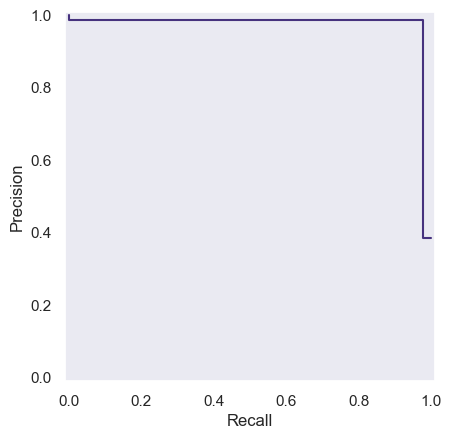

In [111]:
y_train = train['Converted'].astype(int)
X_train_pp = train.drop('Converted', axis=1)

# Ensure X_train_pp_df is always a DataFrame, even if sparse matrix
if hasattr(X_train_pp, "toarray"):
    X_train_pp_df = pd.DataFrame(X_train_pp.toarray(), columns=feature_names)
else:
    X_train_pp_df = X_train_pp.copy()


from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

xgb = XGBClassifier(random_state=42)
xgb_scores = cross_val_score(xgb, X_train_pp, y_train,
                             cv=skfold, scoring='f1', verbose=1, n_jobs=-1)

xgb.fit(X_train_pp, y_train)
xgb_pred = xgb.predict(X_train_pp)

# Precision and recall curve
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

xgb_prec, xgb_recall, xgb_threshold = precision_recall_curve(
    y_train, xgb_pred, pos_label=xgb.classes_[1])
xgb_prdisplay = PrecisionRecallDisplay(precision=xgb_prec, recall=xgb_recall)
xgb_prdisplay.plot()

# Display scores
display_scores(xgb, xgb_scores, xgb_pred)

# SHAP input DataFrame info
print(X_train_pp_df.shape)


### 5.1.3: Hyperparameter Tuning

In [113]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

xgb_params = {
    'n_estimators': randint(50, 500),          # Number of trees
    'max_depth': randint(3, 15),               # Max depth of trees
    'learning_rate': uniform(0.01, 0.3),       # Step size shrinkage
    'subsample': uniform(0.5, 0.5),            # Row subsampling ratio
    'colsample_bytree': uniform(0.5, 0.5),     # Feature subsampling
    'gamma': uniform(0, 5),                    # Min loss reduction for split
    'min_child_weight': randint(1, 10),        # Min sum hessian for split
    'reg_alpha': uniform(0, 1),                # L1 regularization
    'reg_lambda': uniform(0, 1),               # L2 regularization
    'scale_pos_weight': uniform(0.5, 2.5)      # Class imbalance handling
}


xgb_randomcv = RandomizedSearchCV(xgb, xgb_params, cv=skfold,
                                 scoring='f1',
                                 return_train_score = True,
                                 random_state = 10,
                                 n_iter=50, verbose=1, n_jobs=1)

xgb_randomcv.fit(X_train_pp, y_train)

print("--------------- XG Boost --------------")
print("Best Parameters: ", xgb_randomcv.best_params_)
print("Best Score: ", xgb_randomcv.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END colsample_bytree=0.8856603216333729, gamma=0.1037597467970075, learning_rate=0.20009447047788262, max_depth=14, min_child_weight=1, n_estimators=463, reg_alpha=0.19806286475962398, reg_lambda=0.7605307121989587, scale_pos_weight=0.9227770914063387, subsample=0.5441699070870052;, score=(train=0.997, test=0.934) total time=   0.9s
[CV 2/5] END colsample_bytree=0.8856603216333729, gamma=0.1037597467970075, learning_rate=0.20009447047788262, max_depth=14, min_child_weight=1, n_estimators=463, reg_alpha=0.19806286475962398, reg_lambda=0.7605307121989587, scale_pos_weight=0.9227770914063387, subsample=0.5441699070870052;, score=(train=0.997, test=0.927) total time=   0.9s
[CV 3/5] END colsample_bytree=0.8856603216333729, gamma=0.1037597467970075, learning_rate=0.20009447047788262, max_depth=14, min_child_weight=1, n_estimators=463, reg_alpha=0.19806286475962398, reg_lambda=0.7605307121989587, scale_pos_weight=0.922777

In [114]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import pandas as pd

def my_confusion_matrix(y_true, y_pred, model, y_proba=None, save_fig=False, fig_name="roc_curve.png"):
    # Confusion Matrix
    cf = confusion_matrix(y_true, y_pred, labels=model.classes_)
    print("\nConfusion Matrix (rows = Actual, columns = Predicted):")
    
    # Format it nicely
    cf_df = pd.DataFrame(cf, index=[f'Actual: {cls}' for cls in model.classes_],
                            columns=[f'Predicted: {cls}' for cls in model.classes_])
    print(cf_df)

    # If probabilities are provided, plot ROC Curve
    if y_proba is not None:
        fpr, tpr, thresholds = roc_curve(y_true, y_proba)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8,6))
        plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guess')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)

        if save_fig:
            plt.savefig(fig_name, dpi=300, bbox_inches='tight')
            print(f"ROC curve saved as {fig_name}")

        plt.show()


### 5.1.4: Preparing test data

In [116]:
y_test = test['Converted'].astype(int)
X_test = test.drop('Converted', axis=1)



# Ensure X_test_pp_df is always a DataFrame, even if X_test is sparse
if hasattr(X_test, "toarray"):
    X_test_pp_df = pd.DataFrame(X_test.toarray(), columns=feature_names)
else:
    X_test_pp_df = X_test.copy()

# Preview the first row of the test set as a NumPy array
print(X_test.shape)


(1848, 74)


### 5.1.4: Testing Optimized XGB Model

In [146]:
X_test_pp=X_test.copy()
xgb_pred_test = xgb_randomcv.predict(X_test_pp)
y_proba = xgb_randomcv.predict_proba(X_test_pp)[:, 1]
print('Optimised Model : XGB')
print("Precision:", precision_score(y_test,xgb_pred_test))
print("Recall:", recall_score(y_test,xgb_pred_test))
print("F1 score:", f1_score(y_test,xgb_pred_test))
print("ROC - AUC score:", roc_auc_score(y_test,xgb_pred_test))
my_confusion_matrix(y_test, xgb_pred_test, xgb_randomcv, y_proba=y_proba, save_fig=True, fig_name="/Users/human1/Documents/HFU/DSResources/XGB_optmised.png")

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:lead origin: object, lead source: object, do not email: object, do not call: object, last activity: object, country: object, specialization: object, how did you hear about x education: object, what is your current occupation: object, what matters most to you in choosing a course: object, search: object, magazine: object, newspaper article: object, x education forums: object, newspaper: object, digital advertisement: object, through recommendations: object, receive more updates about our courses: object, tags: object, lead quality: object, update me on supply chain content: object, get updates on dm content: object, lead profile: object, city: object, i agree to pay the amount through cheque: object, a free copy of mastering the interview: object, last notable activity: object

### 5.1.5: Testing Base XGB Model

Base Model : XGB
Precision: 0.9415121255349501
Recall: 0.9269662921348315
F1 score: 0.9341825902335457
ROC - AUC score: 0.9454373714195285

Confusion Matrix (rows = Actual, columns = Predicted):
           Predicted: 0  Predicted: 1
Actual: 0          1095            41
Actual: 1            52           660
ROC curve saved as /Users/human1/Documents/HFU/DSResources/XGB_base.png


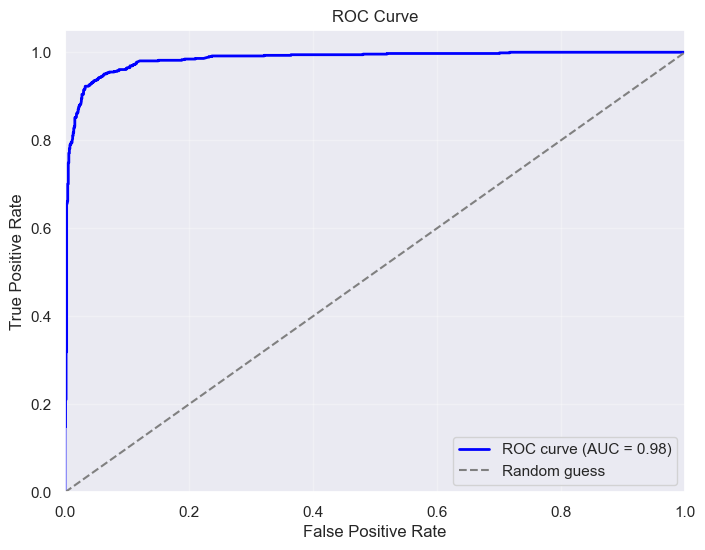

In [120]:
xgb_pred_test_base = xgb.predict(X_test_pp)

y_proba = xgb_randomcv.predict_proba(X_test_pp)[:, 1]

print('Base Model : XGB')

print("Precision:", precision_score(y_test,xgb_pred_test_base))
print("Recall:", recall_score(y_test,xgb_pred_test_base))
print("F1 score:", f1_score(y_test,xgb_pred_test_base))
print("ROC - AUC score:", roc_auc_score(y_test,xgb_pred_test_base))
my_confusion_matrix(y_test, xgb_pred_test_base, xgb, y_proba=y_proba, save_fig=True, fig_name="/Users/human1/Documents/HFU/DSResources/XGB_base.png")


Base Model : XGB
Precision: 0.9415121255349501
Recall: 0.9269662921348315
F1 score: 0.9341825902335457
ROC - AUC score: 0.984078275834784

Confusion Matrix (rows = Actual, columns = Predicted):
           Predicted: 0  Predicted: 1
Actual: 0          1095            41
Actual: 1            52           660
ROC curve saved as /Users/human1/Documents/HFU/DSResources/XGB_base.png


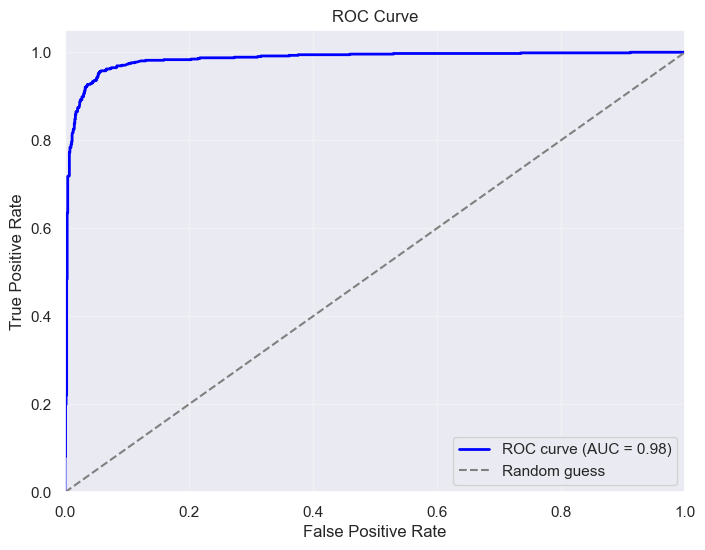

In [121]:
# 1. Define the base model
xgb_base1 = XGBClassifier(random_state=42)

# 2. Fit the base model to the training data
xgb_base1.fit(X_train_pp, y_train)

# 3. Predict on test data
xgb_pred_test_base = xgb_base1.predict(X_test_pp)

# 4. Predict probabilities for ROC-AUC and visualization
y_proba_base = xgb_base1.predict_proba(X_test_pp)[:, 1]

# 5. Evaluate
print('Base Model : XGB')
print("Precision:", precision_score(y_test, xgb_pred_test_base))
print("Recall:", recall_score(y_test, xgb_pred_test_base))
print("F1 score:", f1_score(y_test, xgb_pred_test_base))
print("ROC - AUC score:", roc_auc_score(y_test, y_proba_base))

# 6. Plot Confusion Matrix (assuming you defined my_confusion_matrix properly)
my_confusion_matrix(
    y_test, 
    xgb_pred_test_base, 
    xgb_base1, 
    y_proba=y_proba_base, 
    save_fig=True, 
    fig_name="/Users/human1/Documents/HFU/DSResources/XGB_base.png"
)


### 5.1.6: Comparison of Precision, Recall, F1 Score, ROC-AUC 

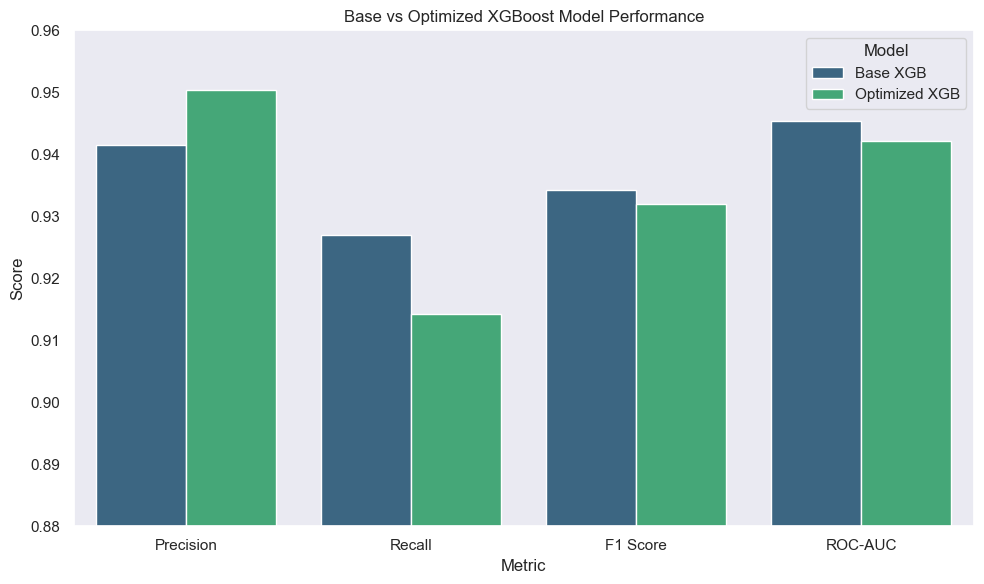

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Metrics for each model
metrics = ['Precision', 'Recall', 'F1 Score', 'ROC-AUC']
base_scores = [0.9415, 0.9270, 0.9342, 0.9454]
opt_scores = [0.9504, 0.9143, 0.9320, 0.9422]

# Create DataFrame
df_plot = pd.DataFrame({
    'Metric': metrics * 2,
    'Score': base_scores + opt_scores,
    'Model': ['Base XGB'] * 4 + ['Optimized XGB'] * 4
})

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Metric', y='Score', hue='Model', palette='viridis')

plt.title('Base vs Optimized XGBoost Model Performance')
plt.ylim(0.88, 0.96)
plt.ylabel('Score')
plt.xlabel('Metric')
plt.legend(title='Model')
plt.tight_layout()
plt.show()


### 5.1.7: Comparison of Confusion Matrix

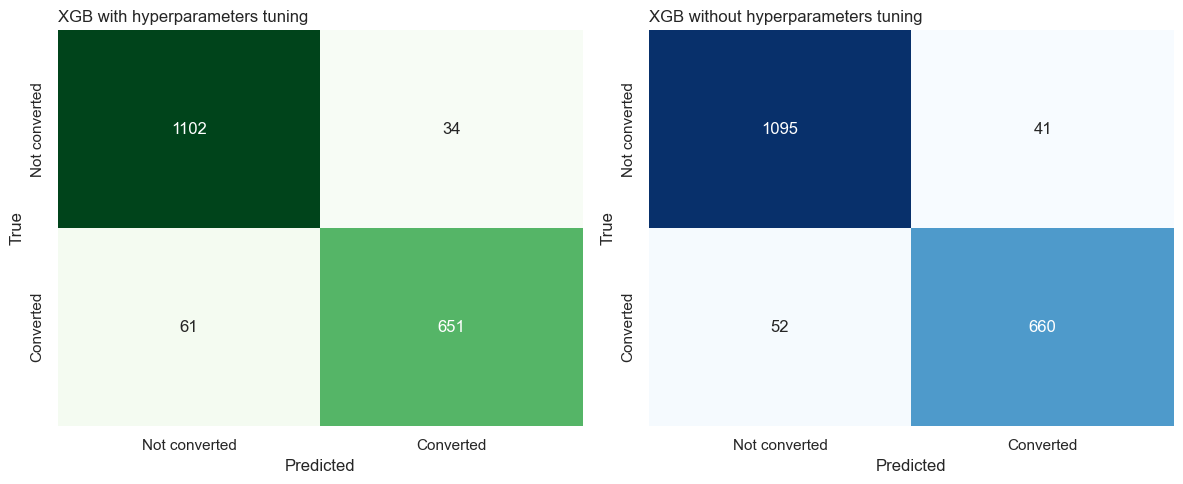

In [125]:
from sklearn.metrics import confusion_matrix
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# XGB  tunned
cm1 = confusion_matrix(y_test, xgb_pred_test)
sns.heatmap(cm1, annot=True, fmt = 'd', cmap='Greens', ax = ax[0], cbar=False)
ax[0].xaxis.set_ticklabels(['Not converted', 'Converted'])
ax[0].yaxis.set_ticklabels(['Not converted', 'Converted'])
ax[0].set_title('XGB with hyperparameters tuning', loc='left')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')

# XGB without tuning
cm2 = confusion_matrix(y_test, xgb_pred_test_base)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', ax=ax[1], cbar=False)
ax[1].xaxis.set_ticklabels(['Not converted', 'Converted'])
ax[1].yaxis.set_ticklabels(['Not converted', 'Converted'])
ax[1].set_title('XGB without hyperparameters tuning', loc='left')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('/Users/human1/Documents/HFU/DSResources/XGBModel1.png',bbox_inches='tight' )
plt.show()

### 5.1.8: Shap Analysis and Feature Importance

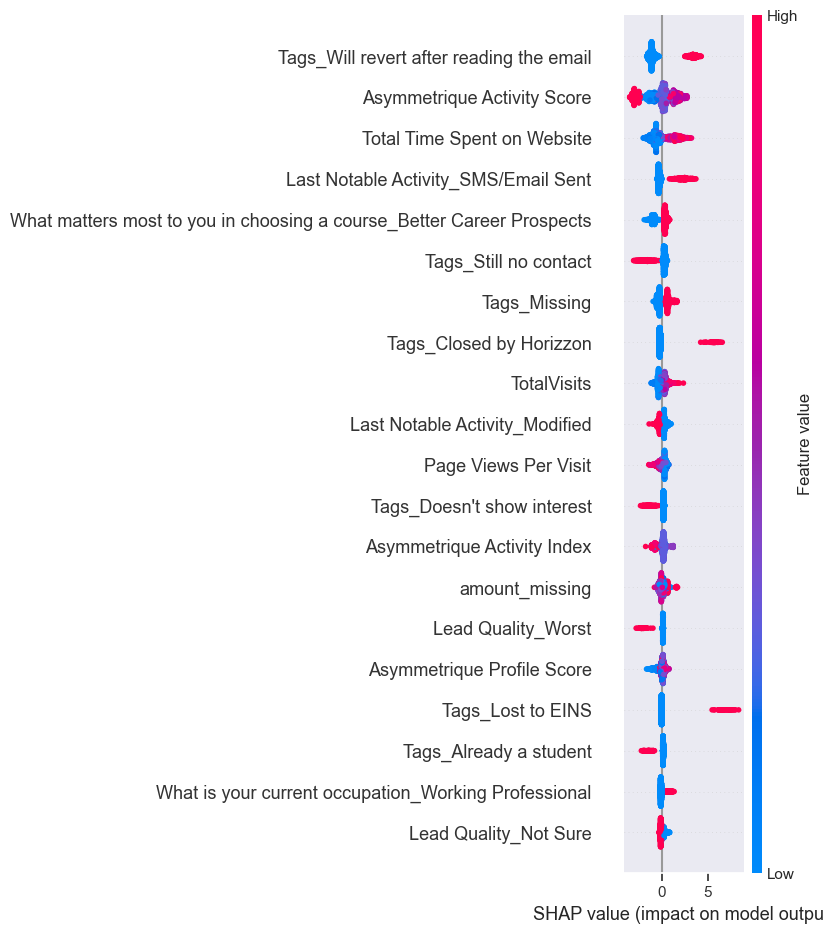

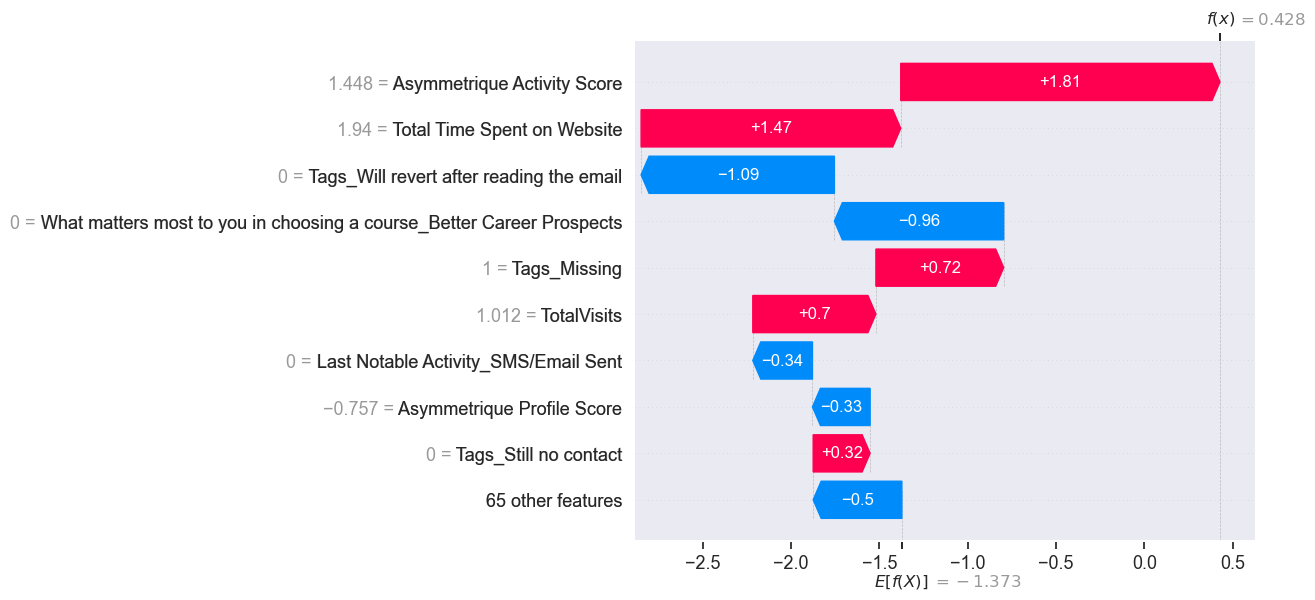

In [127]:
import shap

# Initialize the TreeExplainer
explainer = shap.Explainer(xgb, X_train_pp_df)

# Compute SHAP values for the test set
shap_values = explainer(X_test_pp_df)

# Summary plot (global explanation)
shap.summary_plot(shap_values, X_test_pp_df)

# Choose an individual prediction to explain
index_to_explain = 0  # can be changed
shap.plots.waterfall(shap_values[index_to_explain])

shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[index_to_explain].values, X_test_pp_df.iloc[index_to_explain])


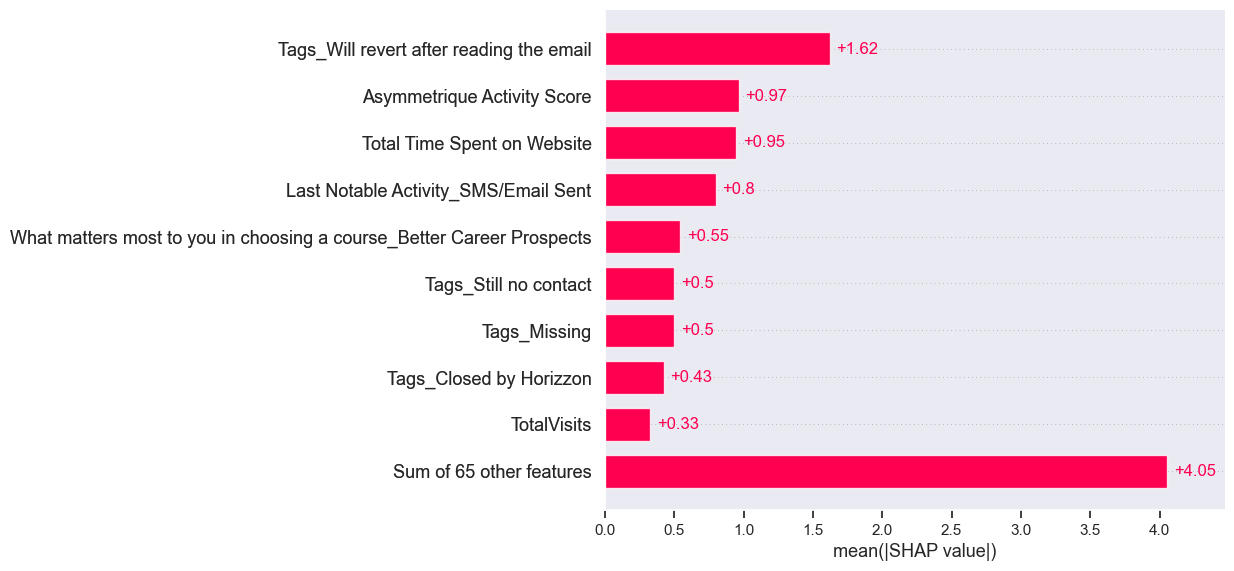

In [128]:
# ✅ 2. SHAP Bar Plot - average absolute SHAP value
shap.plots.bar(shap_values)


## 5.2: Anjali Modeling

### 1️⃣  Separate target and features

In [154]:
# Keep the raw DataFrame from previous steps; drop the label from X
target_col = "Converted"
y = df[target_col].astype(int)                         # label as ints
X = df.drop(columns=[target_col]).copy()               # all features

### 2️⃣  Rebuild column lists EXCLUDING the target

In [157]:
# Guarantees no data leakage when numeric list originally held label
cat_cols_model = [c for c in cat_columns]              # all categoricals
num_cols_model = [c for c in num_cols if c != target_col]  # drop label

### 3️⃣  Re-assemble preprocessing (same logic, new lists)

In [160]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

pipe_cat = make_pipeline(impute_cons, ohe)             # cat branch
pipe_num = make_pipeline(impute_knn, sc)               # num branch

preprocessor_model = make_column_transformer(
    (pipe_cat, cat_cols_model),
    (pipe_num, num_cols_model),
    remainder="drop"
)

model_pipe = make_pipeline(
    initial_feature_engineering_transformer,           # your functions
    eda_feature_engineering_transformer,
    cap_outliers_transformer,
    preprocessor_model                                  # final encoder-scaler
)

### 4️⃣ Train / Trial / Test split  (80 / 10 / 10)

In [163]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, stratify=y, test_size=0.20, random_state=42
)
X_trial, X_test, y_trial, y_test = train_test_split(
    X_temp, y_temp, stratify=y_temp, test_size=0.50, random_state=42
)

### 5️⃣  Fit pipeline on TRAIN only, transform all sets

In [166]:
X_train_pp = model_pipe.fit_transform(X_train)         # learn on train
X_trial_pp = model_pipe.transform(X_trial)             # transform only
X_test_pp  = model_pipe.transform(X_test)


### 6️⃣  Baseline Decision-Tree (no tuning)

In [169]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

baseline_dt = DecisionTreeClassifier(random_state=42)
baseline_dt.fit(X_train_pp, y_train)

print("Baseline F1  – Trial :", f1_score(y_trial, baseline_dt.predict(X_trial_pp)).round(4))
print("Baseline F1  – Test  :", f1_score(y_test , baseline_dt.predict(X_test_pp )).round(4))


Baseline F1  – Trial : 0.9109
Baseline F1  – Test  : 0.8652


### 7️⃣  Hyper-parameter grid + GridSearchCV

In [172]:
param_grid = {
    "criterion"        : ["gini", "entropy", "log_loss"],
    "max_depth"        : [None, 4, 6, 8, 10],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf" : [1, 2, 4, 8],
    "class_weight"     : [None, "balanced"]
}

from sklearn.model_selection import GridSearchCV, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train_pp, y_train)
print("Best Params :", dt_grid.best_params_)
print("Best CV F1  :", dt_grid.best_score_.round(4))

Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Best Params : {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 20}
Best CV F1  : 0.9228


### 8️⃣  Final model – evaluate on TRIAL & TEST

In [174]:
best_dt  = dt_grid.best_estimator_

from sklearn.metrics import (
    precision_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix, RocCurveDisplay
)

def evaluate_set(name, Xp, yt):
    yp     = best_dt.predict(Xp)
    yproba = best_dt.predict_proba(Xp)[:,1]
    print(f"\n {name} Set Report")
    print(classification_report(yt, yp))
    print(f"{name} ROC-AUC: {roc_auc_score(yt, yproba):.4f}")
    return yp, yproba

y_trial_pred, y_trial_proba = evaluate_set("TRIAL", X_trial_pp, y_trial)
y_test_pred , y_test_proba  = evaluate_set("TEST" , X_test_pp , y_test )



 TRIAL Set Report
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       568
           1       0.94      0.93      0.94       356

    accuracy                           0.95       924
   macro avg       0.95      0.95      0.95       924
weighted avg       0.95      0.95      0.95       924

TRIAL ROC-AUC: 0.9802

 TEST Set Report
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       568
           1       0.93      0.88      0.90       356

    accuracy                           0.93       924
   macro avg       0.93      0.92      0.92       924
weighted avg       0.93      0.93      0.93       924

TEST ROC-AUC: 0.9629


### 9️⃣  Confusion matrices

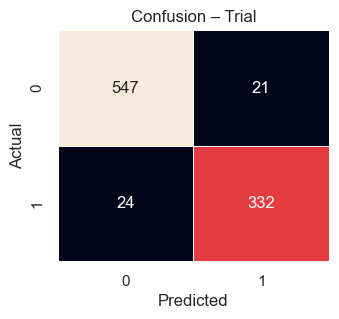

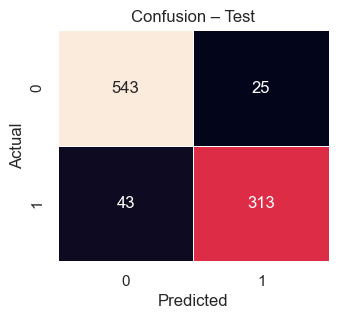

In [185]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cm(cm, title):
    plt.figure(figsize=(3.5,3))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, linewidths=.4)
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

plot_cm(confusion_matrix(y_trial, y_trial_pred), "Confusion – Trial")
plot_cm(confusion_matrix(y_test , y_test_pred ), "Confusion – Test")


### 🔟  ROC curves – Trial vs Test

<Figure size 500x400 with 0 Axes>

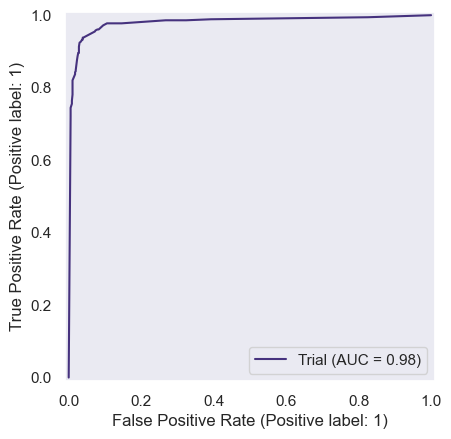

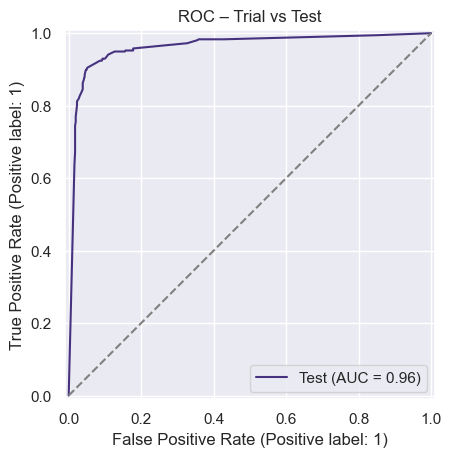

In [191]:
plt.figure(figsize=(5,4))
RocCurveDisplay.from_predictions(y_trial, y_trial_proba, name="Trial")
RocCurveDisplay.from_predictions(y_test , y_test_proba , name="Test")
plt.plot([0,1],[0,1],"--",color="gray"); plt.title("ROC – Trial vs Test"); plt.grid(); plt.show()

### 1️⃣1️⃣ Decision-Tree snapshot (first 3 levels)

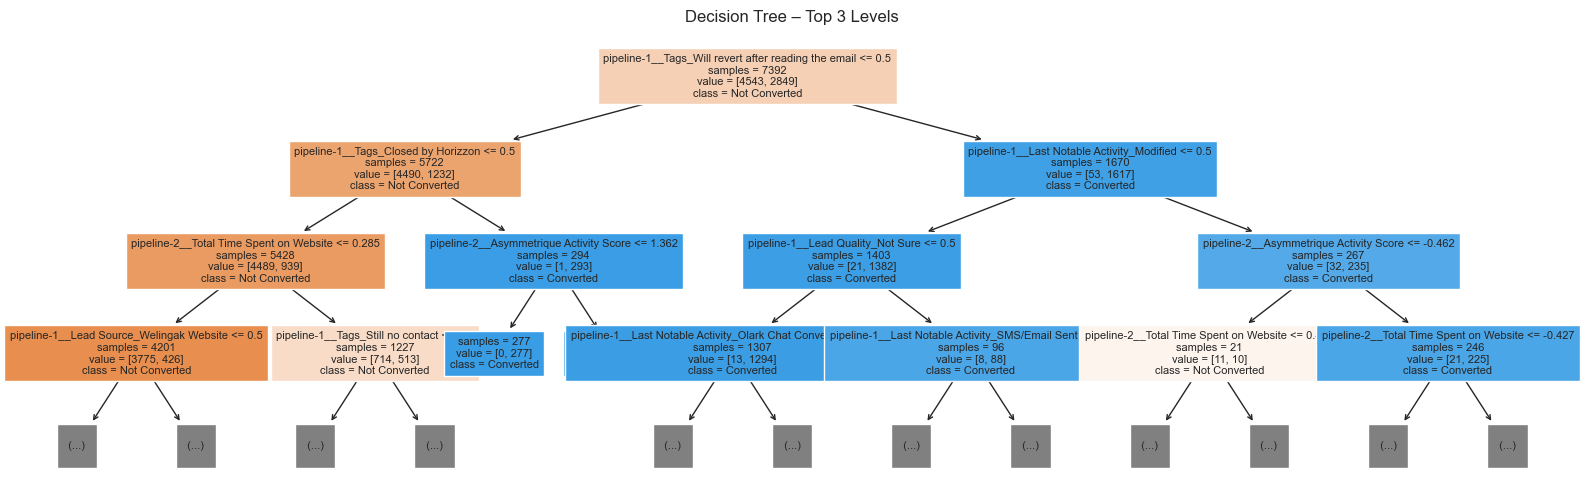

In [221]:
import matplotlib.pyplot as plt
from sklearn import tree 

fig, ax = plt.subplots(figsize=(20, 6))
tree.plot_tree(
    best_dt,
    max_depth=3,                     # show only first 3 levels
    filled=True,
    impurity=False,
    fontsize=8,
    feature_names=feat_names,
    class_names=["Not Converted", "Converted"],
    ax=ax
)
ax.set_title("Decision Tree – Top 3 Levels")
ax.axis('off')                       
plt.show()

### 🔍 Additional Visualizations – Model Diagnostics & Insights

### 1️⃣ Decision Path for a Single Prediction

How one example moves down the tree (“How does this model decide?”)

In [205]:
from sklearn.tree import _tree

def print_decision_path(X_row, model, feature_names):
    tree_ = model.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    node_indicator = model.decision_path(X_row)
    leaf_id = model.apply(X_row)

    print(f"\nDecision Path for input row:")
    for node_id in node_indicator.indices:
        if leaf_id[0] == node_id:
            print(f"--> Predicts at node {node_id}")
        else:
            threshold = tree_.threshold[node_id]
            feat = feature_name[node_id]
            sign = "<=" if X_row[0, tree_.feature[node_id]] <= threshold else ">"
            print(f"Node {node_id}: ({feat} = {X_row[0, tree_.feature[node_id]]:.2f}) {sign} {threshold:.2f}")

# Pick one example from test set
print_decision_path(X_test_pp[0:1], best_dt, feat_names)



Decision Path for input row:
Node 0: (pipeline-1__Tags_Will revert after reading the email = 0.00) <= 0.50
Node 1: (pipeline-1__Tags_Closed by Horizzon = 0.00) <= 0.50
Node 2: (pipeline-2__Total Time Spent on Website = -0.77) <= 0.28
Node 3: (pipeline-1__Lead Source_Welingak Website = 0.00) <= 0.50
Node 4: (pipeline-1__Tags_Lost to EINS = 0.00) <= 0.50
Node 5: (pipeline-1__Last Notable Activity_SMS/Email Sent = 0.00) <= 0.50
Node 6: (pipeline-1__City_Not Provided = 0.00) <= 0.50
Node 7: (pipeline-1__Tags_Busy = 0.00) <= 0.50
Node 8: (pipeline-1__Tags_Other = 0.00) <= 0.50
Node 9: (pipeline-2__Asymmetrique Activity Score = 1.64) > 0.45
--> Predicts at node 11


### 2️⃣ Grid Search Heatmap of Hyperparameters

Visualize performance across max_depth and min_samples_split.

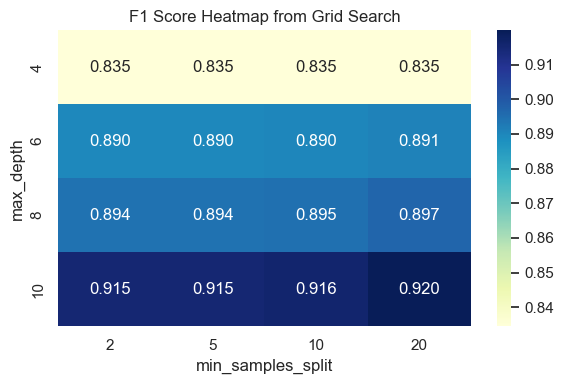

In [209]:
# Extract grid results as a DataFrame
cv_results = pd.DataFrame(dt_grid.cv_results_)
heatmap_data = cv_results.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_min_samples_split'
)

plt.figure(figsize=(6,4))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("F1 Score Heatmap from Grid Search")
plt.xlabel("min_samples_split")
plt.ylabel("max_depth")
plt.tight_layout()
plt.show()


### 3️⃣ Class Balance Visual (Before Splitting)

handling an imbalanced dataset.

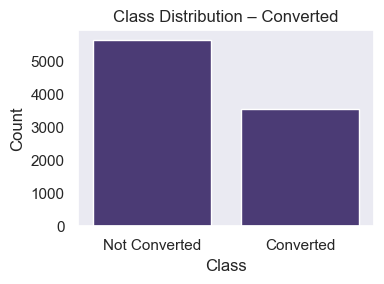

In [213]:
plt.figure(figsize=(4,3))
sns.countplot(x=df["Converted"])
plt.title("Class Distribution – Converted")
plt.xlabel("Class"); plt.ylabel("Count")
plt.xticks([0, 1], ["Not Converted", "Converted"])
plt.tight_layout()
plt.show()


## 5.3: Tzu-Ching Lee Modeling

In [134]:
#for training use below dataset
# X_train_pp, y_train

In [135]:
#for testing use below dataset
#X_test, y_test


In [136]:
#Separate features (X) and target (y)
df.columns = df.columns.str.strip().str.lower()
df.drop(['prospect id', 'lead number'], axis=1, inplace=True)
X = df.drop('converted', axis=1)
y = df['converted']

In [137]:
#Identify numerical and categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# For numeric columns: impute missing with median, then scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

# For categorical columns: fill missing with 'missing', then OneHotEncode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))])

# Combine pipelines into a column transformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)])

pipe = Pipeline([
    ('preprocessor', preprocessor)])

=== Logistic Regression Evaluation (Train Set) ===
Cross-Validated F1 Score: 0.9211174166378182
Accuracy: 0.948051948051948
Precision: 0.945750452079566
Recall: 0.9178659178659179
F1 Score: 0.931599572497328
ROC-AUC: 0.9424240441189594

Confusion Matrix:
 [[4393  150]
 [ 234 2615]]


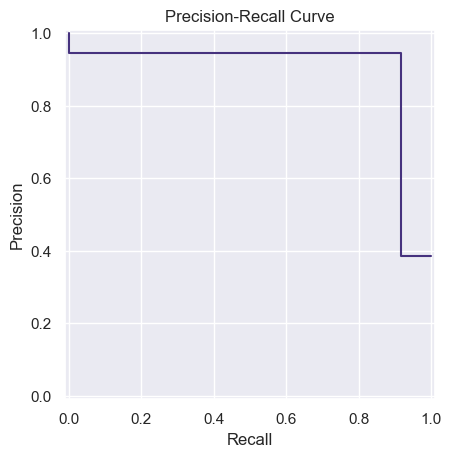

In [138]:
#Split data and apply preprocessing

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_train_pp = pipe.fit_transform(X_train)
#Train and evaluate Logistic Regression model

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt
skfold = StratifiedKFold(n_splits=5)
lr = LogisticRegression(max_iter=5000)
lr_scores = cross_val_score(lr, X_train_pp, y_train, cv=skfold, scoring='f1')

lr.fit(X_train_pp, y_train)
lr_pred = lr.predict(X_train_pp)
#Model evaluation results

print("=== Logistic Regression Evaluation (Train Set) ===")
print("Cross-Validated F1 Score:", lr_scores.mean())
print("Accuracy:", accuracy_score(y_train, lr_pred))
print("Precision:", precision_score(y_train, lr_pred))
print("Recall:", recall_score(y_train, lr_pred))
print("F1 Score:", f1_score(y_train, lr_pred))
print("ROC-AUC:", roc_auc_score(y_train, lr_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, lr_pred))


#Plot Precision-Recall Curve

lr_prec, lr_recall, _ = precision_recall_curve(y_train, lr_pred, pos_label=lr.classes_[1])
lr_prdisplay = PrecisionRecallDisplay(precision=lr_prec, recall=lr_recall)
lr_prdisplay.plot()
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [140]:
#Perform hyperparameter tuning

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

lr_params = {
    'C': uniform(loc=0, scale=4),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']}
lr_randomcv = RandomizedSearchCV(
    LogisticRegression(max_iter=100),
    lr_params,
    cv=skfold,
    scoring='f1',
    return_train_score=True,
    random_state=10,
    n_iter=100,
)
lr_randomcv.fit(X_train_pp, y_train)

print("\n=== RandomizedSearchCV: Logistic Regression Tuning ===")
print("Best Parameters:", lr_randomcv.best_params_)
print("Best F1 Score:", lr_randomcv.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=3.085282573066984, penalty=l1, solver=saga;, score=(train=0.919, test=0.918) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=3.085282573066984, penalty=l1, solver=saga;, score=(train=0.915, test=0.924) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=3.085282573066984, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=3.085282573066984, penalty=l1, solver=saga;, score=(train=0.915, test=0.914) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=3.085282573066984, penalty=l1, solver=saga;, score=(train=0.926, test=0.921) total time=   1.0s
[CV 1/5] END C=2.5345929397051017, penalty=l2, solver=liblinear;, score=(train=0.930, test=0.921) total time=   0.1s
[CV 2/5] END C=2.5345929397051017, penalty=l2, solver=liblinear;, score=(train=0.932, test=0.933) total time=   0.1s
[CV 3/5] END C=2.5345929397051017, penalty=l2, solver=liblinear;, score=(train=0.938, test=0.908) total time=   0.1s
[CV 4/5] END C=2.5345929397051017, penalty=l2, solver=liblinear;, score=(train=0.934, test=0.926) total time=   0.1s
[CV 5/5] END C=2.5345929397051017, penalty=l2, solver=liblinear;, score=(train=0.929, test=0.926) total time=   0.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=1.9940280492103617, penalty=l1, solver=saga;, score=(train=0.918, test=0.918) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=1.9940280492103617, penalty=l1, solver=saga;, score=(train=0.914, test=0.924) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=1.9940280492103617, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=1.9940280492103617, penalty=l1, solver=saga;, score=(train=0.916, test=0.913) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=1.9940280492103617, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=0.7922514590384959, penalty=l1, solver=saga;, score=(train=0.917, test=0.917) total time=   0.8s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=0.7922514590384959, penalty=l1, solver=saga;, score=(train=0.914, test=0.925) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=0.7922514590384959, penalty=l1, solver=saga;, score=(train=0.919, test=0.906) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=0.7922514590384959, penalty=l1, solver=saga;, score=(train=0.914, test=0.911) total time=   1.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=0.7922514590384959, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   1.5s
[CV 1/5] END C=0.6764433462501418, penalty=l1, solver=liblinear;, score=(train=0.926, test=0.921) total time=   0.5s
[CV 2/5] END C=0.6764433462501418, penalty=l1, solver=liblinear;, score=(train=0.929, test=0.937) total time=   0.5s
[CV 3/5] END C=0.6764433462501418, penalty=l1, solver=liblinear;, score=(train=0.933, test=0.910) total time=   0.4s
[CV 4/5] END C=0.6764433462501418, penalty=l1, solver=liblinear;, score=(train=0.930, test=0.922) total time=   0.6s
[CV 5/5] END C=0.6764433462501418, penalty=l1, solver=liblinear;, score=(train=0.928, test=0.928) total time=   0.2s
[CV 1/5] END C=2.741439273471189, penalty=l1, solver=liblinear;, score=(train=0.932, test=0.929) total time=   0.4s
[CV 2/5] END C=2.741439273471189, penalty=l1, solver=liblinear;, score=(train=0.933, test=0.933) total time=   0.6s
[CV 3/5] END C=2.741439273471189, penalty=l1, solver=liblinear;, score=

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=3.250483846608454, penalty=l1, solver=saga;, score=(train=0.919, test=0.918) total time=   1.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=3.250483846608454, penalty=l1, solver=saga;, score=(train=0.914, test=0.924) total time=   1.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=3.250483846608454, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=3.250483846608454, penalty=l1, solver=saga;, score=(train=0.915, test=0.914) total time=   1.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=3.250483846608454, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=2.887021269727198, penalty=l1, solver=saga;, score=(train=0.919, test=0.918) total time=   1.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=2.887021269727198, penalty=l1, solver=saga;, score=(train=0.914, test=0.924) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=2.887021269727198, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=2.887021269727198, penalty=l1, solver=saga;, score=(train=0.915, test=0.914) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=2.887021269727198, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=3.6710964900517737, penalty=l2, solver=saga;, score=(train=0.918, test=0.918) total time=   0.6s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=3.6710964900517737, penalty=l2, solver=saga;, score=(train=0.915, test=0.924) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=3.6710964900517737, penalty=l2, solver=saga;, score=(train=0.920, test=0.906) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=3.6710964900517737, penalty=l2, solver=saga;, score=(train=0.915, test=0.915) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=3.6710964900517737, penalty=l2, solver=saga;, score=(train=0.925, test=0.921) total time=   0.3s
[CV 1/5] END C=2.170177472045045, penalty=l2, solver=liblinear;, score=(train=0.930, test=0.921) total time=   0.1s
[CV 2/5] END C=2.170177472045045, penalty=l2, solver=liblinear;, score=(train=0.932, test=0.933) total time=   0.1s
[CV 3/5] END C=2.170177472045045, penalty=l2, solver=liblinear;, score=(train=0.937, test=0.908) total time=   0.1s
[CV 4/5] END C=2.170177472045045, penalty=l2, solver=liblinear;, score=(train=0.934, test=0.926) total time=   0.1s
[CV 5/5] END C=2.170177472045045, penalty=l2, solver=liblinear;, score=(train=0.929, test=0.926) total time=   0.1s
[CV 1/5] END C=1.4933630402058768, penalty=l1, solver=liblinear;, score=(train=0.930, test=0.928) total time=   0.3s
[CV 2/5] END C=1.4933630402058768, penalty=l1, solver=liblinear;, score=(train=0.932, test=0.934) total time=   0.2s
[CV 3/5] END C=1.4933630402058768, penalty=l1, solver=liblinear;, score=(t

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=1.7673326976919843, penalty=l1, solver=saga;, score=(train=0.919, test=0.917) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=1.7673326976919843, penalty=l1, solver=saga;, score=(train=0.914, test=0.924) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=1.7673326976919843, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=1.7673326976919843, penalty=l1, solver=saga;, score=(train=0.915, test=0.913) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=1.7673326976919843, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=2.4710679138772687, penalty=l1, solver=saga;, score=(train=0.919, test=0.918) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=2.4710679138772687, penalty=l1, solver=saga;, score=(train=0.914, test=0.924) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=2.4710679138772687, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=2.4710679138772687, penalty=l1, solver=saga;, score=(train=0.915, test=0.913) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=2.4710679138772687, penalty=l1, solver=saga;, score=(train=0.926, test=0.921) total time=   1.0s
[CV 1/5] END C=2.601588727725869, penalty=l2, solver=liblinear;, score=(train=0.930, test=0.921) total time=   0.1s
[CV 2/5] END C=2.601588727725869, penalty=l2, solver=liblinear;, score=(train=0.932, test=0.933) total time=   0.1s
[CV 3/5] END C=2.601588727725869, penalty=l2, solver=liblinear;, score=(train=0.938, test=0.908) total time=   0.1s
[CV 4/5] END C=2.601588727725869, penalty=l2, solver=liblinear;, score=(train=0.934, test=0.926) total time=   0.1s
[CV 5/5] END C=2.601588727725869, penalty=l2, solver=liblinear;, score=(train=0.929, test=0.926) total time=   0.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=3.220892787330986, penalty=l1, solver=saga;, score=(train=0.919, test=0.918) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=3.220892787330986, penalty=l1, solver=saga;, score=(train=0.914, test=0.924) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=3.220892787330986, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=3.220892787330986, penalty=l1, solver=saga;, score=(train=0.915, test=0.914) total time=   1.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=3.220892787330986, penalty=l1, solver=saga;, score=(train=0.926, test=0.921) total time=   1.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=3.634595523234673, penalty=l1, solver=saga;, score=(train=0.919, test=0.918) total time=   1.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=3.634595523234673, penalty=l1, solver=saga;, score=(train=0.915, test=0.924) total time=   1.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=3.634595523234673, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=3.634595523234673, penalty=l1, solver=saga;, score=(train=0.915, test=0.913) total time=   1.6s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=3.634595523234673, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   1.3s
[CV 1/5] END C=0.3618373970836295, penalty=l1, solver=liblinear;, score=(train=0.925, test=0.921) total time=   0.3s
[CV 2/5] END C=0.3618373970836295, penalty=l1, solver=liblinear;, score=(train=0.925, test=0.938) total time=   0.3s
[CV 3/5] END C=0.3618373970836295, penalty=l1, solver=liblinear;, score=(train=0.931, test=0.906) total time=   0.2s
[CV 4/5] END C=0.3618373970836295, penalty=l1, solver=liblinear;, score=(train=0.924, test=0.922) total time=   0.4s
[CV 5/5] END C=0.3618373970836295, penalty=l1, solver=liblinear;, score=(train=0.923, test=0.919) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=0.45593744745419906, penalty=l2, solver=saga;, score=(train=0.917, test=0.917) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=0.45593744745419906, penalty=l2, solver=saga;, score=(train=0.914, test=0.924) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=0.45593744745419906, penalty=l2, solver=saga;, score=(train=0.919, test=0.906) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=0.45593744745419906, penalty=l2, solver=saga;, score=(train=0.914, test=0.910) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=0.45593744745419906, penalty=l2, solver=saga;, score=(train=0.922, test=0.919) total time=   0.4s
[CV 1/5] END C=0.18758527755699905, penalty=l2, solver=liblinear;, score=(train=0.922, test=0.920) total time=   0.1s
[CV 2/5] END C=0.18758527755699905, penalty=l2, solver=liblinear;, score=(train=0.920, test=0.928) total time=   0.1s
[CV 3/5] END C=0.18758527755699905, penalty=l2, solver=liblinear;, score=(train=0.925, test=0.906) total time=   0.1s
[CV 4/5] END C=0.18758527755699905, penalty=l2, solver=liblinear;, score=(train=0.921, test=0.915) total time=   0.1s
[CV 5/5] END C=0.18758527755699905, penalty=l2, solver=liblinear;, score=(train=0.919, test=0.914) total time=   0.1s
[CV 1/5] END C=2.190344623676974, penalty=l1, solver=liblinear;, score=(train=0.932, test=0.929) total time=   0.2s
[CV 2/5] END C=2.190344623676974, penalty=l1, solver=liblinear;, score=(train=0.932, test=0.935) total time=   0.5s
[CV 3/5] END C=2.190344623676974, penalty=l1, solver=liblinear;, 

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=1.3020465513289952, penalty=l1, solver=saga;, score=(train=0.918, test=0.917) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=1.3020465513289952, penalty=l1, solver=saga;, score=(train=0.914, test=0.924) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=1.3020465513289952, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=1.3020465513289952, penalty=l1, solver=saga;, score=(train=0.916, test=0.913) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=1.3020465513289952, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=1.5701169757863491, penalty=l1, solver=saga;, score=(train=0.918, test=0.917) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=1.5701169757863491, penalty=l1, solver=saga;, score=(train=0.914, test=0.924) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=1.5701169757863491, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=1.5701169757863491, penalty=l1, solver=saga;, score=(train=0.915, test=0.913) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=1.5701169757863491, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   0.9s
[CV 1/5] END C=3.284422631347714, penalty=l2, solver=liblinear;, score=(train=0.931, test=0.921) total time=   0.1s
[CV 2/5] END C=3.284422631347714, penalty=l2, solver=liblinear;, score=(train=0.933, test=0.933) total time=   0.1s
[CV 3/5] END C=3.284422631347714, penalty=l2, solver=liblinear;, score=(train=0.938, test=0.907) total time=   0.1s
[CV 4/5] END C=3.284422631347714, penalty=l2, solver=liblinear;, score=(train=0.934, test=0.926) total time=   0.1s
[CV 5/5] END C=3.284422631347714, penalty=l2, solver=liblinear;, score=(train=0.930, test=0.926) total time=   0.1s
[CV 1/5] END C=1.5364577947687983, penalty=l1, solver=liblinear;, score=(train=0.930, test=0.927) total time=   0.2s
[CV 2/5] END C=1.5364577947687983, penalty=l1, solver=liblinear;, score=(train=0.932, test=0.935) total time=   0.3s
[CV 3/5] END C=1.5364577947687983, penalty=l1, solver=liblinear;, score=(t

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=3.950501899607489, penalty=l2, solver=saga;, score=(train=0.918, test=0.918) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=3.950501899607489, penalty=l2, solver=saga;, score=(train=0.915, test=0.924) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=3.950501899607489, penalty=l2, solver=saga;, score=(train=0.921, test=0.906) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=3.950501899607489, penalty=l2, solver=saga;, score=(train=0.915, test=0.915) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=3.950501899607489, penalty=l2, solver=saga;, score=(train=0.925, test=0.921) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=3.3044913753709593, penalty=l1, solver=saga;, score=(train=0.919, test=0.918) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=3.3044913753709593, penalty=l1, solver=saga;, score=(train=0.914, test=0.924) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=3.3044913753709593, penalty=l1, solver=saga;, score=(train=0.921, test=0.905) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=3.3044913753709593, penalty=l1, solver=saga;, score=(train=0.916, test=0.914) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=3.3044913753709593, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   1.1s
[CV 1/5] END C=2.389486592923537, penalty=l2, solver=liblinear;, score=(train=0.930, test=0.921) total time=   0.1s
[CV 2/5] END C=2.389486592923537, penalty=l2, solver=liblinear;, score=(train=0.932, test=0.933) total time=   0.1s
[CV 3/5] END C=2.389486592923537, penalty=l2, solver=liblinear;, score=(train=0.938, test=0.908) total time=   0.1s
[CV 4/5] END C=2.389486592923537, penalty=l2, solver=liblinear;, score=(train=0.934, test=0.926) total time=   0.1s
[CV 5/5] END C=2.389486592923537, penalty=l2, solver=liblinear;, score=(train=0.929, test=0.926) total time=   0.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=2.1382317952072603, penalty=l2, solver=saga;, score=(train=0.918, test=0.918) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=2.1382317952072603, penalty=l2, solver=saga;, score=(train=0.915, test=0.924) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=2.1382317952072603, penalty=l2, solver=saga;, score=(train=0.920, test=0.906) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=2.1382317952072603, penalty=l2, solver=saga;, score=(train=0.915, test=0.915) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=2.1382317952072603, penalty=l2, solver=saga;, score=(train=0.925, test=0.921) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=0.15712706890154937, penalty=l1, solver=saga;, score=(train=0.914, test=0.910) total time=   0.6s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=0.15712706890154937, penalty=l1, solver=saga;, score=(train=0.910, test=0.926) total time=   0.6s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=0.15712706890154937, penalty=l1, solver=saga;, score=(train=0.917, test=0.899) total time=   0.6s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=0.15712706890154937, penalty=l1, solver=saga;, score=(train=0.910, test=0.907) total time=   0.6s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=0.15712706890154937, penalty=l1, solver=saga;, score=(train=0.919, test=0.918) total time=   0.5s
[CV 1/5] END C=0.31845236062385673, penalty=l1, solver=liblinear;, score=(train=0.925, test=0.921) total time=   0.3s
[CV 2/5] END C=0.31845236062385673, penalty=l1, solver=liblinear;, score=(train=0.920, test=0.937) total time=   0.3s
[CV 3/5] END C=0.31845236062385673, penalty=l1, solver=liblinear;, score=(train=0.930, test=0.906) total time=   0.1s
[CV 4/5] END C=0.31845236062385673, penalty=l1, solver=liblinear;, score=(train=0.923, test=0.921) total time=   0.2s
[CV 5/5] END C=0.31845236062385673, penalty=l1, solver=liblinear;, score=(train=0.924, test=0.919) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=1.322877247928528, penalty=l1, solver=saga;, score=(train=0.918, test=0.917) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=1.322877247928528, penalty=l1, solver=saga;, score=(train=0.915, test=0.924) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=1.322877247928528, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=1.322877247928528, penalty=l1, solver=saga;, score=(train=0.916, test=0.913) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=1.322877247928528, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   0.9s
[CV 1/5] END C=0.15983683475990906, penalty=l2, solver=liblinear;, score=(train=0.920, test=0.919) total time=   0.1s
[CV 2/5] END C=0.15983683475990906, penalty=l2, solver=liblinear;, score=(train=0.919, test=0.928) total time=   0.1s
[CV 3/5] END C=0.15983683475990906, penalty=l2, solver=liblinear;, score=(train=0.924, test=0.906) total time=   0.1s
[CV 4/5] END C=0.15983683475990906, penalty=l2, solver=liblinear;, score=(train=0.919, test=0.913) total time=   0.1s
[CV 5/5] END C=0.15983683475990906, penalty=l2, solver=liblinear;, score=(train=0.918, test=0.912) total time=   0.1s
[CV 1/5] END C=1.2597074873707532, penalty=l1, solver=liblinear;, score=(train=0.930, test=0.927) total time=   0.3s
[CV 2/5] END C=1.2597074873707532, penalty=l1, solver=liblinear;, score=(train=0.932, test=0.935) total time=   0.3s
[CV 3/5] END C=1.2597074873707532, penalty=l1, solver=liblinear;,

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=1.3853886003201321, penalty=l1, solver=saga;, score=(train=0.918, test=0.917) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=1.3853886003201321, penalty=l1, solver=saga;, score=(train=0.914, test=0.924) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=1.3853886003201321, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=1.3853886003201321, penalty=l1, solver=saga;, score=(train=0.916, test=0.913) total time=   1.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=1.3853886003201321, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   1.3s
[CV 1/5] END C=3.519660698071664, penalty=l2, solver=liblinear;, score=(train=0.930, test=0.921) total time=   0.2s
[CV 2/5] END C=3.519660698071664, penalty=l2, solver=liblinear;, score=(train=0.933, test=0.933) total time=   0.2s
[CV 3/5] END C=3.519660698071664, penalty=l2, solver=liblinear;, score=(train=0.937, test=0.908) total time=   0.1s
[CV 4/5] END C=3.519660698071664, penalty=l2, solver=liblinear;, score=(train=0.934, test=0.926) total time=   0.1s
[CV 5/5] END C=3.519660698071664, penalty=l2, solver=liblinear;, score=(train=0.930, test=0.926) total time=   0.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=3.5123865708994333, penalty=l1, solver=saga;, score=(train=0.919, test=0.918) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=3.5123865708994333, penalty=l1, solver=saga;, score=(train=0.915, test=0.924) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=3.5123865708994333, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=3.5123865708994333, penalty=l1, solver=saga;, score=(train=0.915, test=0.915) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=3.5123865708994333, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   1.1s
[CV 1/5] END C=2.422310257575027, penalty=l1, solver=liblinear;, score=(train=0.932, test=0.929) total time=   0.2s
[CV 2/5] END C=2.422310257575027, penalty=l1, solver=liblinear;, score=(train=0.933, test=0.934) total time=   0.5s
[CV 3/5] END C=2.422310257575027, penalty=l1, solver=liblinear;, score=(train=0.937, test=0.909) total time=   0.3s
[CV 4/5] END C=2.422310257575027, penalty=l1, solver=liblinear;, score=(train=0.934, test=0.925) total time=   0.4s
[CV 5/5] END C=2.422310257575027, penalty=l1, solver=liblinear;, score=(train=0.929, test=0.927) total time=   0.4s
[CV 1/5] END C=2.3913465918518946, penalty=l2, solver=liblinear;, score=(train=0.930, test=0.921) total time=   0.1s
[CV 2/5] END C=2.3913465918518946, penalty=l2, solver=liblinear;, score=(train=0.932, test=0.933) total time=   0.1s
[CV 3/5] END C=2.3913465918518946, penalty=l2, solver=liblinear;, score=(t

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=1.212250242604139, penalty=l1, solver=saga;, score=(train=0.918, test=0.917) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=1.212250242604139, penalty=l1, solver=saga;, score=(train=0.915, test=0.924) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=1.212250242604139, penalty=l1, solver=saga;, score=(train=0.920, test=0.906) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=1.212250242604139, penalty=l1, solver=saga;, score=(train=0.915, test=0.910) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=1.212250242604139, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=2.2303127546505768, penalty=l2, solver=saga;, score=(train=0.918, test=0.918) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=2.2303127546505768, penalty=l2, solver=saga;, score=(train=0.915, test=0.924) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=2.2303127546505768, penalty=l2, solver=saga;, score=(train=0.920, test=0.906) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=2.2303127546505768, penalty=l2, solver=saga;, score=(train=0.916, test=0.915) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=2.2303127546505768, penalty=l2, solver=saga;, score=(train=0.925, test=0.921) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=1.9005289896602022, penalty=l1, solver=saga;, score=(train=0.918, test=0.917) total time=   1.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=1.9005289896602022, penalty=l1, solver=saga;, score=(train=0.914, test=0.924) total time=   1.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=1.9005289896602022, penalty=l1, solver=saga;, score=(train=0.920, test=0.906) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=1.9005289896602022, penalty=l1, solver=saga;, score=(train=0.915, test=0.913) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=1.9005289896602022, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=0.2570042427792978, penalty=l1, solver=saga;, score=(train=0.917, test=0.915) total time=   0.8s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=0.2570042427792978, penalty=l1, solver=saga;, score=(train=0.915, test=0.925) total time=   0.8s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=0.2570042427792978, penalty=l1, solver=saga;, score=(train=0.918, test=0.904) total time=   0.8s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=0.2570042427792978, penalty=l1, solver=saga;, score=(train=0.912, test=0.909) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=0.2570042427792978, penalty=l1, solver=saga;, score=(train=0.922, test=0.920) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=1.3588313745514546, penalty=l2, solver=saga;, score=(train=0.918, test=0.918) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=1.3588313745514546, penalty=l2, solver=saga;, score=(train=0.915, test=0.924) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=1.3588313745514546, penalty=l2, solver=saga;, score=(train=0.920, test=0.906) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=1.3588313745514546, penalty=l2, solver=saga;, score=(train=0.915, test=0.915) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=1.3588313745514546, penalty=l2, solver=saga;, score=(train=0.925, test=0.921) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=3.908322903690727, penalty=l2, solver=saga;, score=(train=0.918, test=0.918) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=3.908322903690727, penalty=l2, solver=saga;, score=(train=0.915, test=0.924) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=3.908322903690727, penalty=l2, solver=saga;, score=(train=0.920, test=0.906) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=3.908322903690727, penalty=l2, solver=saga;, score=(train=0.916, test=0.915) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=3.908322903690727, penalty=l2, solver=saga;, score=(train=0.925, test=0.921) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=1.2730912219158048, penalty=l2, solver=saga;, score=(train=0.918, test=0.917) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=1.2730912219158048, penalty=l2, solver=saga;, score=(train=0.915, test=0.924) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=1.2730912219158048, penalty=l2, solver=saga;, score=(train=0.920, test=0.906) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=1.2730912219158048, penalty=l2, solver=saga;, score=(train=0.915, test=0.914) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=1.2730912219158048, penalty=l2, solver=saga;, score=(train=0.925, test=0.921) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=2.31254571952987, penalty=l2, solver=saga;, score=(train=0.918, test=0.918) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=2.31254571952987, penalty=l2, solver=saga;, score=(train=0.915, test=0.924) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=2.31254571952987, penalty=l2, solver=saga;, score=(train=0.920, test=0.906) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=2.31254571952987, penalty=l2, solver=saga;, score=(train=0.916, test=0.915) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=2.31254571952987, penalty=l2, solver=saga;, score=(train=0.925, test=0.921) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=0.2723890941518001, penalty=l2, solver=saga;, score=(train=0.917, test=0.916) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=0.2723890941518001, penalty=l2, solver=saga;, score=(train=0.914, test=0.922) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=0.2723890941518001, penalty=l2, solver=saga;, score=(train=0.919, test=0.904) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=0.2723890941518001, penalty=l2, solver=saga;, score=(train=0.913, test=0.907) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=0.2723890941518001, penalty=l2, solver=saga;, score=(train=0.920, test=0.918) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=3.1277964744765936, penalty=l1, solver=saga;, score=(train=0.919, test=0.918) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=3.1277964744765936, penalty=l1, solver=saga;, score=(train=0.914, test=0.924) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=3.1277964744765936, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=3.1277964744765936, penalty=l1, solver=saga;, score=(train=0.915, test=0.914) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=3.1277964744765936, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=2.3440879202127034, penalty=l2, solver=saga;, score=(train=0.918, test=0.918) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=2.3440879202127034, penalty=l2, solver=saga;, score=(train=0.915, test=0.924) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=2.3440879202127034, penalty=l2, solver=saga;, score=(train=0.920, test=0.906) total time=   0.6s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=2.3440879202127034, penalty=l2, solver=saga;, score=(train=0.916, test=0.915) total time=   0.8s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=2.3440879202127034, penalty=l2, solver=saga;, score=(train=0.925, test=0.921) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=1.402625565132532, penalty=l2, solver=saga;, score=(train=0.918, test=0.918) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=1.402625565132532, penalty=l2, solver=saga;, score=(train=0.915, test=0.924) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=1.402625565132532, penalty=l2, solver=saga;, score=(train=0.920, test=0.906) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=1.402625565132532, penalty=l2, solver=saga;, score=(train=0.915, test=0.914) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=1.402625565132532, penalty=l2, solver=saga;, score=(train=0.925, test=0.921) total time=   0.3s
[CV 1/5] END C=1.1989194896982514, penalty=l2, solver=liblinear;, score=(train=0.929, test=0.920) total time=   0.1s
[CV 2/5] END C=1.1989194896982514, penalty=l2, solver=liblinear;, score=(train=0.932, test=0.932) total time=   0.1s
[CV 3/5] END C=1.1989194896982514, penalty=l2, solver=liblinear;, score=(train=0.935, test=0.910) total time=   0.1s
[CV 4/5] END C=1.1989194896982514, penalty=l2, solver=liblinear;, score=(train=0.932, test=0.926) total time=   0.1s
[CV 5/5] END C=1.1989194896982514, penalty=l2, solver=liblinear;, score=(train=0.926, test=0.922) total time=   0.1s
[CV 1/5] END C=2.693867701138882, penalty=l2, solver=liblinear;, score=(train=0.930, test=0.920) total time=   0.1s
[CV 2/5] END C=2.693867701138882, penalty=l2, solver=liblinear;, score=(train=0.932, test=0.933) total time=   0.1s
[CV 3/5] END C=2.693867701138882, penalty=l2, solver=liblinear;, score=(

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=0.2019106806159905, penalty=l1, solver=saga;, score=(train=0.915, test=0.910) total time=   0.6s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=0.2019106806159905, penalty=l1, solver=saga;, score=(train=0.913, test=0.924) total time=   0.7s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=0.2019106806159905, penalty=l1, solver=saga;, score=(train=0.917, test=0.904) total time=   0.7s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=0.2019106806159905, penalty=l1, solver=saga;, score=(train=0.911, test=0.908) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=0.2019106806159905, penalty=l1, solver=saga;, score=(train=0.920, test=0.919) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=0.43225509111781024, penalty=l2, solver=saga;, score=(train=0.917, test=0.916) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=0.43225509111781024, penalty=l2, solver=saga;, score=(train=0.914, test=0.924) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=0.43225509111781024, penalty=l2, solver=saga;, score=(train=0.919, test=0.905) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=0.43225509111781024, penalty=l2, solver=saga;, score=(train=0.914, test=0.909) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=0.43225509111781024, penalty=l2, solver=saga;, score=(train=0.922, test=0.919) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=3.543308384670823, penalty=l2, solver=saga;, score=(train=0.918, test=0.918) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=3.543308384670823, penalty=l2, solver=saga;, score=(train=0.915, test=0.924) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=3.543308384670823, penalty=l2, solver=saga;, score=(train=0.920, test=0.906) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=3.543308384670823, penalty=l2, solver=saga;, score=(train=0.916, test=0.915) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=3.543308384670823, penalty=l2, solver=saga;, score=(train=0.925, test=0.921) total time=   0.5s
[CV 1/5] END C=0.8750773967181469, penalty=l1, solver=liblinear;, score=(train=0.927, test=0.921) total time=   0.4s
[CV 2/5] END C=0.8750773967181469, penalty=l1, solver=liblinear;, score=(train=0.930, test=0.936) total time=   0.2s
[CV 3/5] END C=0.8750773967181469, penalty=l1, solver=liblinear;, score=(train=0.933, test=0.911) total time=   0.1s
[CV 4/5] END C=0.8750773967181469, penalty=l1, solver=liblinear;, score=(train=0.930, test=0.924) total time=   0.3s
[CV 5/5] END C=0.8750773967181469, penalty=l1, solver=liblinear;, score=(train=0.929, test=0.928) total time=   0.3s
[CV 1/5] END C=0.4275183375742766, penalty=l1, solver=liblinear;, score=(train=0.926, test=0.921) total time=   0.3s
[CV 2/5] END C=0.4275183375742766, penalty=l1, solver=liblinear;, score=(train=0.926, test=0.936) total time=   0.2s
[CV 3/5] END C=0.4275183375742766, penalty=l1, solver=liblinear;, scor

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=2.5802885058729674, penalty=l2, solver=saga;, score=(train=0.918, test=0.918) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=2.5802885058729674, penalty=l2, solver=saga;, score=(train=0.915, test=0.924) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=2.5802885058729674, penalty=l2, solver=saga;, score=(train=0.920, test=0.906) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=2.5802885058729674, penalty=l2, solver=saga;, score=(train=0.916, test=0.915) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=2.5802885058729674, penalty=l2, solver=saga;, score=(train=0.925, test=0.921) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=0.9944500312110778, penalty=l2, solver=saga;, score=(train=0.918, test=0.917) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=0.9944500312110778, penalty=l2, solver=saga;, score=(train=0.915, test=0.924) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=0.9944500312110778, penalty=l2, solver=saga;, score=(train=0.920, test=0.906) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=0.9944500312110778, penalty=l2, solver=saga;, score=(train=0.915, test=0.913) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=0.9944500312110778, penalty=l2, solver=saga;, score=(train=0.923, test=0.921) total time=   0.4s
[CV 1/5] END C=0.9070933730800368, penalty=l1, solver=liblinear;, score=(train=0.927, test=0.922) total time=   0.2s
[CV 2/5] END C=0.9070933730800368, penalty=l1, solver=liblinear;, score=(train=0.930, test=0.935) total time=   0.2s
[CV 3/5] END C=0.9070933730800368, penalty=l1, solver=liblinear;, score=(train=0.933, test=0.911) total time=   0.2s
[CV 4/5] END C=0.9070933730800368, penalty=l1, solver=liblinear;, score=(train=0.931, test=0.925) total time=   0.2s
[CV 5/5] END C=0.9070933730800368, penalty=l1, solver=liblinear;, score=(train=0.929, test=0.928) total time=   0.3s
[CV 1/5] END C=3.688931147614185, penalty=l1, solver=liblinear;, score=(train=0.932, test=0.930) total time=   0.3s
[CV 2/5] END C=3.688931147614185, penalty=l1, solver=liblinear;, score=(train=0.933, test=0.932) total time=   0.6s
[CV 3/5] END C=3.688931147614185, penalty=l1, solver=liblinear;, score=

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=2.2921156161327434, penalty=l1, solver=saga;, score=(train=0.919, test=0.918) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=2.2921156161327434, penalty=l1, solver=saga;, score=(train=0.914, test=0.924) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=2.2921156161327434, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=2.2921156161327434, penalty=l1, solver=saga;, score=(train=0.915, test=0.913) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=2.2921156161327434, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   1.0s
[CV 1/5] END C=2.2462294411054757, penalty=l2, solver=liblinear;, score=(train=0.929, test=0.921) total time=   0.1s
[CV 2/5] END C=2.2462294411054757, penalty=l2, solver=liblinear;, score=(train=0.932, test=0.933) total time=   0.1s
[CV 3/5] END C=2.2462294411054757, penalty=l2, solver=liblinear;, score=(train=0.937, test=0.908) total time=   0.1s
[CV 4/5] END C=2.2462294411054757, penalty=l2, solver=liblinear;, score=(train=0.934, test=0.926) total time=   0.1s
[CV 5/5] END C=2.2462294411054757, penalty=l2, solver=liblinear;, score=(train=0.929, test=0.926) total time=   0.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=2.336783314122702, penalty=l2, solver=saga;, score=(train=0.918, test=0.918) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=2.336783314122702, penalty=l2, solver=saga;, score=(train=0.915, test=0.924) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=2.336783314122702, penalty=l2, solver=saga;, score=(train=0.920, test=0.906) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=2.336783314122702, penalty=l2, solver=saga;, score=(train=0.916, test=0.915) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=2.336783314122702, penalty=l2, solver=saga;, score=(train=0.925, test=0.921) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=0.5941338054258343, penalty=l2, solver=saga;, score=(train=0.918, test=0.917) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=0.5941338054258343, penalty=l2, solver=saga;, score=(train=0.914, test=0.924) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=0.5941338054258343, penalty=l2, solver=saga;, score=(train=0.920, test=0.906) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=0.5941338054258343, penalty=l2, solver=saga;, score=(train=0.914, test=0.912) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=0.5941338054258343, penalty=l2, solver=saga;, score=(train=0.922, test=0.921) total time=   0.5s
[CV 1/5] END C=2.7755602653696467, penalty=l2, solver=liblinear;, score=(train=0.930, test=0.920) total time=   0.1s
[CV 2/5] END C=2.7755602653696467, penalty=l2, solver=liblinear;, score=(train=0.933, test=0.933) total time=   0.2s
[CV 3/5] END C=2.7755602653696467, penalty=l2, solver=liblinear;, score=(train=0.938, test=0.908) total time=   0.2s
[CV 4/5] END C=2.7755602653696467, penalty=l2, solver=liblinear;, score=(train=0.934, test=0.927) total time=   0.2s
[CV 5/5] END C=2.7755602653696467, penalty=l2, solver=liblinear;, score=(train=0.929, test=0.926) total time=   0.1s
[CV 1/5] END C=1.758420951098362, penalty=l1, solver=liblinear;, score=(train=0.930, test=0.928) total time=   0.5s
[CV 2/5] END C=1.758420951098362, penalty=l1, solver=liblinear;, score=(train=0.932, test=0.935) total time=   0.7s
[CV 3/5] END C=1.758420951098362, penalty=l1, solver=liblinear;, score=

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=1.1836150488833495, penalty=l1, solver=saga;, score=(train=0.918, test=0.917) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=1.1836150488833495, penalty=l1, solver=saga;, score=(train=0.915, test=0.924) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=1.1836150488833495, penalty=l1, solver=saga;, score=(train=0.920, test=0.906) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=1.1836150488833495, penalty=l1, solver=saga;, score=(train=0.915, test=0.910) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=1.1836150488833495, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=0.1227393614917851, penalty=l2, solver=saga;, score=(train=0.914, test=0.910) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=0.1227393614917851, penalty=l2, solver=saga;, score=(train=0.913, test=0.925) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=0.1227393614917851, penalty=l2, solver=saga;, score=(train=0.917, test=0.901) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=0.1227393614917851, penalty=l2, solver=saga;, score=(train=0.911, test=0.908) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=0.1227393614917851, penalty=l2, solver=saga;, score=(train=0.915, test=0.907) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=2.979456307800271, penalty=l1, solver=saga;, score=(train=0.919, test=0.918) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=2.979456307800271, penalty=l1, solver=saga;, score=(train=0.915, test=0.924) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=2.979456307800271, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=2.979456307800271, penalty=l1, solver=saga;, score=(train=0.915, test=0.915) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=2.979456307800271, penalty=l1, solver=saga;, score=(train=0.926, test=0.921) total time=   1.4s
[CV 1/5] END C=1.540454398261946, penalty=l1, solver=liblinear;, score=(train=0.930, test=0.927) total time=   0.4s
[CV 2/5] END C=1.540454398261946, penalty=l1, solver=liblinear;, score=(train=0.932, test=0.935) total time=   0.5s
[CV 3/5] END C=1.540454398261946, penalty=l1, solver=liblinear;, score=(train=0.935, test=0.909) total time=   0.2s
[CV 4/5] END C=1.540454398261946, penalty=l1, solver=liblinear;, score=(train=0.932, test=0.925) total time=   0.3s
[CV 5/5] END C=1.540454398261946, penalty=l1, solver=liblinear;, score=(train=0.929, test=0.928) total time=   0.5s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=3.3530452828147714, penalty=l1, solver=saga;, score=(train=0.919, test=0.918) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=3.3530452828147714, penalty=l1, solver=saga;, score=(train=0.915, test=0.924) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=3.3530452828147714, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=3.3530452828147714, penalty=l1, solver=saga;, score=(train=0.915, test=0.915) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=3.3530452828147714, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=3.1308592729798845, penalty=l2, solver=saga;, score=(train=0.918, test=0.918) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=3.1308592729798845, penalty=l2, solver=saga;, score=(train=0.915, test=0.924) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=3.1308592729798845, penalty=l2, solver=saga;, score=(train=0.920, test=0.906) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=3.1308592729798845, penalty=l2, solver=saga;, score=(train=0.915, test=0.915) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=3.1308592729798845, penalty=l2, solver=saga;, score=(train=0.925, test=0.921) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=2.4126519034481393, penalty=l1, solver=saga;, score=(train=0.918, test=0.918) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=2.4126519034481393, penalty=l1, solver=saga;, score=(train=0.914, test=0.924) total time=   1.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=2.4126519034481393, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=2.4126519034481393, penalty=l1, solver=saga;, score=(train=0.915, test=0.913) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=2.4126519034481393, penalty=l1, solver=saga;, score=(train=0.926, test=0.921) total time=   1.0s
[CV 1/5] END C=2.462947504134277, penalty=l2, solver=liblinear;, score=(train=0.930, test=0.921) total time=   0.1s
[CV 2/5] END C=2.462947504134277, penalty=l2, solver=liblinear;, score=(train=0.932, test=0.933) total time=   0.1s
[CV 3/5] END C=2.462947504134277, penalty=l2, solver=liblinear;, score=(train=0.938, test=0.908) total time=   0.1s
[CV 4/5] END C=2.462947504134277, penalty=l2, solver=liblinear;, score=(train=0.934, test=0.926) total time=   0.1s
[CV 5/5] END C=2.462947504134277, penalty=l2, solver=liblinear;, score=(train=0.929, test=0.926) total time=   0.1s
[CV 1/5] END C=3.001858441949964, penalty=l1, solver=liblinear;, score=(train=0.932, test=0.929) total time=   0.4s
[CV 2/5] END C=3.001858441949964, penalty=l1, solver=liblinear;, score=(train=0.933, test=0.932) total time=   0.5s
[CV 3/5] END C=3.001858441949964, penalty=l1, solver=liblinear;, score=(trai

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=1.9360835611473033, penalty=l2, solver=saga;, score=(train=0.918, test=0.918) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=1.9360835611473033, penalty=l2, solver=saga;, score=(train=0.915, test=0.924) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=1.9360835611473033, penalty=l2, solver=saga;, score=(train=0.920, test=0.906) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=1.9360835611473033, penalty=l2, solver=saga;, score=(train=0.916, test=0.915) total time=   0.4s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=1.9360835611473033, penalty=l2, solver=saga;, score=(train=0.925, test=0.921) total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=0.6992555792884776, penalty=l1, solver=saga;, score=(train=0.918, test=0.916) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=0.6992555792884776, penalty=l1, solver=saga;, score=(train=0.914, test=0.926) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=0.6992555792884776, penalty=l1, solver=saga;, score=(train=0.919, test=0.903) total time=   0.9s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=0.6992555792884776, penalty=l1, solver=saga;, score=(train=0.915, test=0.910) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=0.6992555792884776, penalty=l1, solver=saga;, score=(train=0.924, test=0.920) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=3.3950562872449286, penalty=l1, solver=saga;, score=(train=0.919, test=0.918) total time=   1.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=3.3950562872449286, penalty=l1, solver=saga;, score=(train=0.915, test=0.924) total time=   1.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=3.3950562872449286, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=3.3950562872449286, penalty=l1, solver=saga;, score=(train=0.915, test=0.914) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=3.3950562872449286, penalty=l1, solver=saga;, score=(train=0.926, test=0.921) total time=   1.2s
[CV 1/5] END C=1.8267901412806888, penalty=l2, solver=liblinear;, score=(train=0.929, test=0.922) total time=   0.1s
[CV 2/5] END C=1.8267901412806888, penalty=l2, solver=liblinear;, score=(train=0.931, test=0.933) total time=   0.1s
[CV 3/5] END C=1.8267901412806888, penalty=l2, solver=liblinear;, score=(train=0.937, test=0.909) total time=   0.1s
[CV 4/5] END C=1.8267901412806888, penalty=l2, solver=liblinear;, score=(train=0.934, test=0.926) total time=   0.1s
[CV 5/5] END C=1.8267901412806888, penalty=l2, solver=liblinear;, score=(train=0.929, test=0.926) total time=   0.1s
[CV 1/5] END C=0.46691804378785307, penalty=l2, solver=liblinear;, score=(train=0.926, test=0.920) total time=   0.1s
[CV 2/5] END C=0.46691804378785307, penalty=l2, solver=liblinear;, score=(train=0.929, test=0.933) total time=   0.1s
[CV 3/5] END C=0.46691804378785307, penalty=l2, solver=liblinear;, 

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=0.30834161766415447, penalty=l1, solver=saga;, score=(train=0.917, test=0.916) total time=   0.7s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=0.30834161766415447, penalty=l1, solver=saga;, score=(train=0.915, test=0.925) total time=   0.7s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=0.30834161766415447, penalty=l1, solver=saga;, score=(train=0.918, test=0.905) total time=   0.8s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=0.30834161766415447, penalty=l1, solver=saga;, score=(train=0.912, test=0.908) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=0.30834161766415447, penalty=l1, solver=saga;, score=(train=0.923, test=0.920) total time=   0.8s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=2.2951049258048086, penalty=l1, solver=saga;, score=(train=0.919, test=0.918) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=2.2951049258048086, penalty=l1, solver=saga;, score=(train=0.914, test=0.924) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=2.2951049258048086, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=2.2951049258048086, penalty=l1, solver=saga;, score=(train=0.915, test=0.913) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=2.2951049258048086, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END C=2.6229069708583928, penalty=l1, solver=saga;, score=(train=0.919, test=0.918) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 2/5] END C=2.6229069708583928, penalty=l1, solver=saga;, score=(train=0.914, test=0.924) total time=   1.1s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END C=2.6229069708583928, penalty=l1, solver=saga;, score=(train=0.921, test=0.906) total time=   1.2s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 4/5] END C=2.6229069708583928, penalty=l1, solver=saga;, score=(train=0.915, test=0.914) total time=   1.0s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END C=2.6229069708583928, penalty=l1, solver=saga;, score=(train=0.925, test=0.921) total time=   1.0s
[CV 1/5] END C=1.404854011985635, penalty=l2, solver=liblinear;, score=(train=0.928, test=0.921) total time=   0.1s
[CV 2/5] END C=1.404854011985635, penalty=l2, solver=liblinear;, score=(train=0.931, test=0.932) total time=   0.1s
[CV 3/5] END C=1.404854011985635, penalty=l2, solver=liblinear;, score=(train=0.936, test=0.910) total time=   0.1s
[CV 4/5] END C=1.404854011985635, penalty=l2, solver=liblinear;, score=(train=0.933, test=0.926) total time=   0.1s
[CV 5/5] END C=1.404854011985635, penalty=l2, solver=liblinear;, score=(train=0.929, test=0.927) total time=   0.1s

=== RandomizedSearchCV: Logistic Regression Tuning ===
Best Parameters: {'C': 1.758420951098362, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1 Score: 0.9253722561066123


=== Logistic Regression Evaluation (Test Set) ===
Accuracy: 0.9361471861471862
Precision: 0.9329446064139941
Recall: 0.898876404494382
F1 Score: 0.9155937052932761
ROC-AUC: 0.9291917233739516
Confusion Matrix:
 [[1090   46]
 [  72  640]]


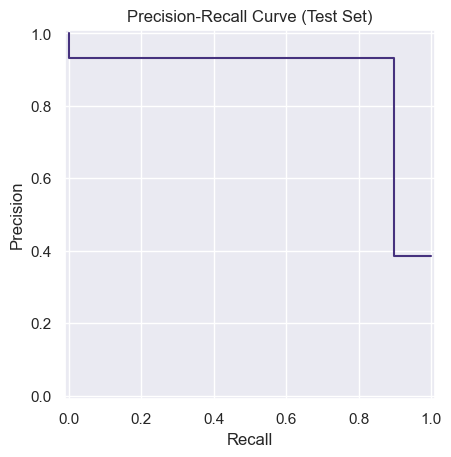

In [142]:
# ===== Evaluate Logistic Regression on Test Data =====

X_test_pp = pipe.transform(X_test)
y_test_pred = lr.predict(X_test_pp)
#Model Evaluation Test Set
print("=== Logistic Regression Evaluation (Test Set) ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

#Plot Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_test_pred, pos_label=lr.classes_[1])
disp = PrecisionRecallDisplay(precision=prec, recall=rec)
disp.plot()
plt.title("Precision-Recall Curve (Test Set)")
plt.grid(True)
plt.show()


=== Final Logistic Regression Evaluation (Test Set) ===
Accuracy: 0.9356060606060606
Precision: 0.9315866084425036
Recall: 0.898876404494382
F1 Score: 0.9149392423159399
ROC-AUC: 0.9287515825288811
Confusion Matrix:
 [[1089   47]
 [  72  640]]


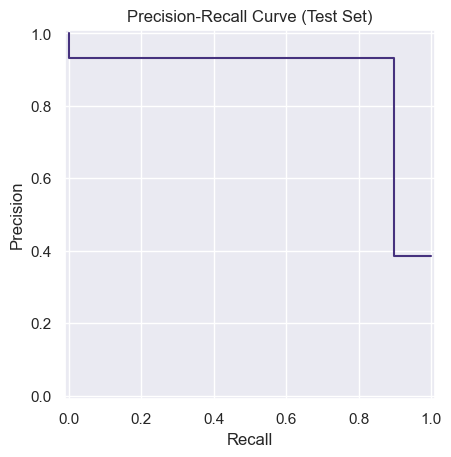

In [144]:
# === Final Evaluation on Test Set ===

#Construct the final model based on the optimal parameters.
final_model = LogisticRegression(max_iter=5000, **lr_randomcv.best_params_)
final_model.fit(X_train_pp, y_train)

#Make predictions on the test data
y_test_pred = final_model.predict(X_test_pp)

#Evaluation on the test set
print("\n=== Final Logistic Regression Evaluation (Test Set) ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

# Precision-Recall Curve
test_prec, test_rec, _ = precision_recall_curve(y_test, y_test_pred, pos_label=final_model.classes_[1])
test_disp = PrecisionRecallDisplay(precision=test_prec, recall=test_rec)
test_disp.plot()
plt.title("Precision-Recall Curve (Test Set)")
plt.grid(True)
plt.show()


# 6:Model Comparison

# 7:Conclusion